# Estimating poly(A) tail length with Nanopolish polyA

Code for producing Figures 2 and S2 on poly(A) tail length in Arabidopsis and ERCC reads

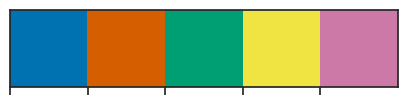

In [1]:
import sys
import os
from glob import glob
import random
from collections import Counter

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib_venn as vn
from matplotlib.colors import ListedColormap
import seaborn as sns

import pysam

## Default plotting params

%matplotlib inline
sns.set(font='Arial')
plt.rcParams['svg.fonttype'] = 'none'
style = sns.axes_style('white')
style.update(sns.axes_style('ticks'))
style['xtick.major.size'] = 2
style['ytick.major.size'] = 2
sns.set(font_scale=1.5, style=style)
pal = sns.color_palette(['#0072b2', '#d55e00', '#009e73', '#f0e442', '#cc79a7'])
cmap = ListedColormap(pal.as_hex())
sns.set_palette(pal)
sns.palplot(pal)
plt.show()

In [2]:
'../../../raw_data/A*/nanopolish/polya_results_new_isoquant_transcriptome.tsv'.split('/')[4]

'A*'

In [2]:
polya_lengths_apo = {}

for fn in [x for x in glob('../../../raw_data/A*/nanopolish/polya_results_new_isoquant_transcriptome.tsv') if 'ERCC' not in x]:
    sample = fn.split('/')[4]
    p = pd.read_table(
        fn, sep='\t',
        usecols=['readname', 'contig', 'position', 'polya_length', 'qc_tag'],
        na_values=['-1'],
        dtype={'readname': str, 'contig': str, 'position': int, 'polya_length': float, 'qc_tag': 'category'},
        index_col='readname'
    )
    #p = p[p['qc_tag'] == 'PASS']
    p['sample']=sample
    polya_lengths_apo[sample] = p
polya_lengths_apo = pd.concat(polya_lengths_apo, axis=0)
polya_lengths_apo.head()

contig  \
   readname                                                                          
A4 fc170a3d-51e8-4622-8afd-b9ba05885825                               AIPGENE19183   
   5c9feae1-ef95-4962-8ea1-ba19151f769a                               AIPGENE19833   
   16ddfc73-b358-45be-a823-7b231e02a8bd  transcript2785.scaffold1003size19901.nnic   
   fd6e6307-5dc0-4b20-a92d-5836993d20e1                               AIPGENE12227   
   22555f35-7beb-4c36-a30a-559ed620128f  transcript2785.scaffold1003size19901.nnic   

                                         position  polya_length qc_tag sample  
   readname                                                                    
A4 fc170a3d-51e8-4622-8afd-b9ba05885825       169         82.04   PASS     A4  
   5c9feae1-ef95-4962-8ea1-ba19151f769a      1664         76.34   PASS     A4  
   16ddfc73-b358-45be-a823-7b231e02a8bd       851         13.28   PASS     A4  
   fd6e6307-5dc0-4b20-a92d-5836993d20e1      2021        253.73   PASS     A4  
   22555f35-7beb-4c36-a30a-559ed620128f       947        146.96   PASS     A4

In [3]:
p

,contig,position,polya_length,qc_tag,sample
readname,,,,,
566cca34-59c5-4fd6-bb95-9d8de3125302,transcript2302.scaffold1000size19988.nnic,320,147.14,PASS,A1
589a3f2d-56bf-4dd4-b9da-dfe61eb0c6fb,transcript2302.scaffold1000size19988.nnic,128,83.83,PASS,A1
93e2b02a-e77c-4e48-aa74-0c204afc96f2,AIPGENE19183,667,120.00,SUFFCLIP,A1
e2574b5b-3862-4fd9-ae60-566610c92a7c,transcript2302.scaffold1000size19988.nnic,5,69.71,PASS,A1
b161bbd9-8dcd-48d1-8926-9115fe7d4332,transcript2785.scaffold1003size19901.nnic,515,38.14,PASS,A1
...,...,...,...,...,...
7c403e21-4a49-4d74-93fe-6b7b89ad995c,AIPGENE4012,124,114.96,PASS,A1
e4d42980-b1dd-4aef-8909-34718eca0c05,AIPGENE3936,2994,120.61,ADAPTER,A1
c0332f2b-ef4a-4917-b637-fa309668dc65,AIPGENE3936,1797,34.26,PASS,A1


In [4]:
polya_lengths_holo = {}

for fn in [x for x in glob('../../../raw_data/H*/nanopolish/polya_results_new_isoquant_transcriptome.tsv') if 'ERCC' not in x]:
    sample = fn.split('/')[4]
    print(sample)
    p = pd.read_table(
        fn, sep='\t',
        usecols=['readname', 'contig', 'position', 'polya_length', 'qc_tag'],
        na_values=['-1'],
        dtype={'readname': str, 'contig': str, 'position': int, 'polya_length': float, 'qc_tag': 'category'},
        index_col='readname'
    )
    #p = p[p['qc_tag'] == 'PASS']
    p['sample']=sample
    polya_lengths_holo[sample] = p
polya_lengths_holo = pd.concat(polya_lengths_holo, axis=0)
polya_lengths_holo.head()

H4
H3
H2
H1


contig  \
   readname                                                                          
H4 122d412b-7274-4e8a-bff5-b8760f2def58                               AIPGENE12227   
   d3aedcca-91b0-4609-b929-1dfe432c873d  transcript1040.scaffold100size601457.nnic   
   cf7cb7d6-23f5-4dbd-8c73-2699fb4aed2b  transcript2785.scaffold1003size19901.nnic   
   2cc068af-20df-4868-9a89-a2eb98b76dc8  transcript2785.scaffold1003size19901.nnic   
   e9164166-c64b-4833-be33-ad80a1c4d40c                               AIPGENE25170   

                                         position  polya_length qc_tag sample  
   readname                                                                    
H4 122d412b-7274-4e8a-bff5-b8760f2def58      2013        144.26   PASS     H4  
   d3aedcca-91b0-4609-b929-1dfe432c873d      1441         65.55   PASS     H4  
   cf7cb7d6-23f5-4dbd-8c73-2699fb4aed2b       740         48.52   PASS     H4  
   2cc068af-20df-4868-9a89-a2eb98b76dc8       702         18.52   PASS     H4  
   e9164166-c64b-4833-be33-ad80a1c4d40c      3166         36.62   PASS     H4

In [5]:
np.unique(polya_lengths_apo['sample'])

array(['A1', 'A2', 'A3', 'A4'], dtype=object)

In [14]:
polya_lengths_apo=polya_lengths_apo[polya_lengths_apo['sample'].isin(['A1','A2','A3'])]
polya_lengths_holo=polya_lengths_holo[polya_lengths_holo['sample'].isin(['H1','H2','H3'])]

In [7]:
polya_lengths_apo.qc_tag.value_counts()

qc_tag
PASS                4417395
ADAPTER             2655401
READ_FAILED_LOAD     408288
SUFFCLIP             305196
NOREGION              87893
Name: count, dtype: int64

In [8]:
polya_lengths_holo.qc_tag.value_counts()

qc_tag
PASS                3668681
ADAPTER             2236848
READ_FAILED_LOAD     592408
SUFFCLIP             209959
NOREGION              81256
Name: count, dtype: int64

In [9]:
sum(polya_lengths_apo.qc_tag == 'PASS') / len(polya_lengths_apo)

0.5609979613097147

In [10]:
sum(polya_lengths_holo.qc_tag == 'PASS') / len(polya_lengths_holo)

0.5403739671758712

In [6]:
polya_lengths_apo = polya_lengths_apo[polya_lengths_apo['qc_tag'] == 'PASS']

In [7]:
polya_lengths_holo = polya_lengths_holo[polya_lengths_holo['qc_tag'] == 'PASS']

In [9]:
polya_lengths_apo.groupby("sample")["polya_length"].describe(percentiles=[0.025, 0.25, 0.50, 0.75, 0.975])

,count,mean,std,min,2.5%,25%,50%,75%,97.5%,max
sample,,,,,,,,,,
A1,1041932.0,75.938562,50.420442,0.00,10.12000,37.0000,65.680,104.7000,195.00000,665.62
A2,951080.0,81.617782,54.026956,0.00,9.22000,39.5000,71.460,114.5200,206.71025,725.96
A3,2424383.0,75.935540,49.621846,0.00,10.15000,38.3400,66.120,103.8200,193.55000,751.55
A4,820.0,98.785902,49.336604,8.42,21.20825,65.1675,94.425,126.0125,222.15500,330.08


In [10]:
polya_lengths_holo.groupby("sample")["polya_length"].describe(percentiles=[0.025, 0.25, 0.50, 0.75, 0.975])

,count,mean,std,min,2.5%,25%,50%,75%,97.5%,max
sample,,,,,,,,,,
H1,524285.0,65.576875,44.790701,0.0,8.14,31.72,56.03,89.38,173.250,676.37
H2,1565800.0,75.466596,51.469618,0.0,9.33,36.21,64.59,103.96,199.320,810.05
H3,1578596.0,75.230069,51.874855,0.0,8.76,35.34,64.10,104.30,199.720,694.22
H4,77318.0,84.982418,54.866279,0.0,12.81,41.23,74.81,118.21,212.073,595.17


In [11]:
polya_lengths_holo.groupby("sample")["contig"].count()

sample
H1     524285
H2    1565800
H3    1578596
H4      77318
Name: contig, dtype: int64

In [12]:
polya_lengths_holo.groupby("sample")["contig"].nunique()

sample
H1    21650
H2    18283
H3    26471
H4     6608
Name: contig, dtype: int64

In [13]:
polya_lengths_apo.groupby("sample")["contig"].nunique()

sample
A1    24380
A2    24244
A3    24670
A4       49
Name: contig, dtype: int64

In [13]:
polya_lengths_apo.contig.unique

<bound method Series.unique of     readname                            
A3  bdc4b5f0-296f-4511-b141-b7df2a27155a    transcript2302.scaffold1000size19988.nnic
    38fddfe7-91ee-47a6-84ad-33b5cfe14a25                                 AIPGENE19183
    298ec2e7-37e6-46d1-888e-24c769d4bbd3    transcript2302.scaffold1000size19988.nnic
    df32de9f-90f8-4545-8b17-f59c2928d573    transcript2302.scaffold1000size19988.nnic
    bfb37d15-3116-43f0-adfe-4589b8834695    transcript2302.scaffold1000size19988.nnic
                                                              ...                    
A1  727321e7-1258-433a-8441-4125d4c8fabf                                  AIPGENE4012
    bea50c5f-8076-485d-8c95-75c0cfb64a57                                  AIPGENE4012
    7c403e21-4a49-4d74-93fe-6b7b89ad995c                                  AIPGENE4012
    c0332f2b-ef4a-4917-b637-fa309668dc65                                  AIPGENE3936
    e1d46fbe-dc61-4506-b3ae-b0ecda512c4f                            

/tmp/ipykernel_279725/3831226823.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(polya_lengths_apo.dropna().polya_length,
/tmp/ipykernel_279725/3831226823.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(polya_lengths_holo.dropna().polya_length,


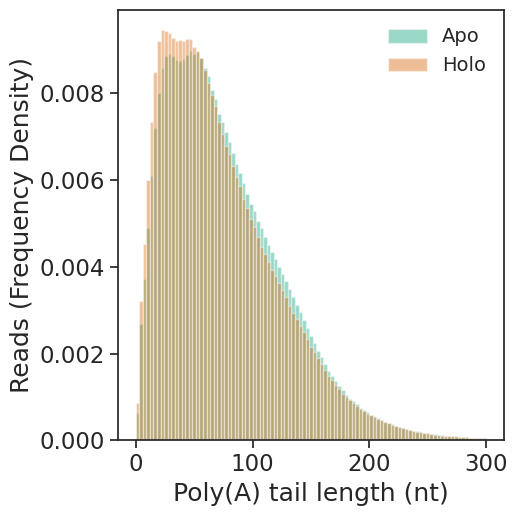

In [14]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))

sns.distplot(polya_lengths_apo.dropna().polya_length,
             hist=True, kde=False,
             bins=np.linspace(0, 300, 100),
             hist_kws={'density': True},
             color=pal[2],
             label='Apo')
sns.distplot(polya_lengths_holo.dropna().polya_length,
             hist=True, kde=False,
             bins=np.linspace(0, 300, 100),
             hist_kws={'density': True},
             color=pal[1],
             label='Holo')
ax.set_xlabel('Poly(A) tail length (nt)')
ax.set_ylabel('Reads (Frequency Density)')
#ax.set_xticks([0, 1, 2, 3])
#ax.set_xticklabels([1, 10, 100, 1000])
#ax.set_xlim(-1, 2.75)
ax.legend(fontsize=14,frameon=False)
plt.tight_layout()
plt.savefig('polya_tail_length_dist_only_6_samples_isoquant.png', transparent=True,dpi=300)
plt.show()

In [15]:
len(polya_lengths_apo.contig.unique())

28906

In [16]:
len(polya_lengths_holo.contig.unique())

28475

In [17]:
polya_lengths_apo

contig  \
   readname                                                                          
A3 bdc4b5f0-296f-4511-b141-b7df2a27155a  transcript2302.scaffold1000size19988.nnic   
   38fddfe7-91ee-47a6-84ad-33b5cfe14a25                               AIPGENE19183   
   298ec2e7-37e6-46d1-888e-24c769d4bbd3  transcript2302.scaffold1000size19988.nnic   
   df32de9f-90f8-4545-8b17-f59c2928d573  transcript2302.scaffold1000size19988.nnic   
   bfb37d15-3116-43f0-adfe-4589b8834695  transcript2302.scaffold1000size19988.nnic   
...                                                                            ...   
A1 727321e7-1258-433a-8441-4125d4c8fabf                                AIPGENE4012   
   bea50c5f-8076-485d-8c95-75c0cfb64a57                                AIPGENE4012   
   7c403e21-4a49-4d74-93fe-6b7b89ad995c                                AIPGENE4012   
   c0332f2b-ef4a-4917-b637-fa309668dc65                                AIPGENE3936   
   e1d46fbe-dc61-4506-b3ae-b0ecda512c4f                                AIPGENE3936   

                                         position  polya_length qc_tag sample  
   readname                                                                    
A3 bdc4b5f0-296f-4511-b141-b7df2a27155a       443         22.17   PASS     A3  
   38fddfe7-91ee-47a6-84ad-33b5cfe14a25       150         51.07   PASS     A3  
   298ec2e7-37e6-46d1-888e-24c769d4bbd3         8         21.00   PASS     A3  
   df32de9f-90f8-4545-8b17-f59c2928d573       401        167.89   PASS     A3  
   bfb37d15-3116-43f0-adfe-4589b8834695        60        129.64   PASS     A3  
...                                           ...           ...    ...    ...  
A1 727321e7-1258-433a-8441-4125d4c8fabf      1441         12.09   PASS     A1  
   bea50c5f-8076-485d-8c95-75c0cfb64a57      1407         30.92   PASS     A1  
   7c403e21-4a49-4d74-93fe-6b7b89ad995c       124        114.96   PASS     A1  
   c0332f2b-ef4a-4917-b637-fa309668dc65      1797         34.26   PASS     A1  
   e1d46fbe-dc61-4506-b3ae-b0ecda512c4f      2670        209.61   PASS     A1  

[4417395 rows x 5 columns]

In [18]:
polya_lengths_apo.polya_length.describe(percentiles=(0.025, 0.25, 0.50, 0.75, 0.975))

count    4.417395e+06
mean     7.715966e+01
std      5.084219e+01
min      0.000000e+00
2.5%     9.930000e+00
25%      3.826000e+01
50%      6.704000e+01
75%      1.063200e+02
97.5%    1.972100e+02
max      7.515500e+02
Name: polya_length, dtype: float64

In [19]:
polya_lengths_holo.polya_length.describe(percentiles=(0.025, 0.25, 0.50, 0.75, 0.975))

count    3.668681e+06
mean     7.395150e+01
std      5.086225e+01
min      0.000000e+00
2.5%     8.900000e+00
25%      3.513000e+01
50%      6.300000e+01
75%      1.019700e+02
97.5%    1.964200e+02
max      8.100500e+02
Name: polya_length, dtype: float64

In [20]:
len(np.unique(polya_lengths_apo.contig))

28906

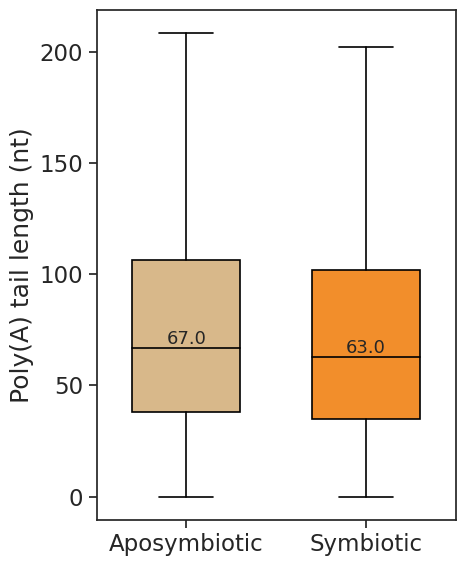

In [30]:
import matplotlib.pyplot as plt

polya_lengths_apo_values = polya_lengths_apo["polya_length"]
polya_lengths_holo_values = polya_lengths_holo["polya_length"]

data = [
    polya_lengths_apo_values.dropna(),
    polya_lengths_holo_values.dropna()
]
#colors = ["#C49A6C", "#F28E2B"]
colors = ["#D8B88A", "#F28E2B"]

medians = [np.median(x) for x in data]

plt.figure(figsize=(5, 6))
labels = ["Aposymbiotic", "Symbiotic"]
bp = plt.boxplot(
    data,
    labels=labels,
    patch_artist=True,
    showfliers=False,
    widths=0.6
)

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor("black")
    patch.set_linewidth(1.2)

# color other elements
for element in ["whiskers", "caps", "medians"]:
    for item in bp[element]:
        item.set_color("black")
        item.set_linewidth(1.2)

for i, median in enumerate(medians, start=1):
    plt.text(
        i, median,
        f"{median:.1f}",
        ha="center",
        va="bottom",
        fontsize=13,
        #fontweight="bold"
    )

plt.ylabel("Poly(A) tail length (nt)")
plt.tight_layout()

plt.savefig("polya_length_boxplot_colored_isoquant.png", dpi=300, bbox_inches="tight")
plt.show()

In [31]:
polya_lengths_apo

contig  \
   readname                                                                          
A3 bdc4b5f0-296f-4511-b141-b7df2a27155a  transcript2302.scaffold1000size19988.nnic   
   38fddfe7-91ee-47a6-84ad-33b5cfe14a25                               AIPGENE19183   
   298ec2e7-37e6-46d1-888e-24c769d4bbd3  transcript2302.scaffold1000size19988.nnic   
   df32de9f-90f8-4545-8b17-f59c2928d573  transcript2302.scaffold1000size19988.nnic   
   bfb37d15-3116-43f0-adfe-4589b8834695  transcript2302.scaffold1000size19988.nnic   
...                                                                            ...   
A1 727321e7-1258-433a-8441-4125d4c8fabf                                AIPGENE4012   
   bea50c5f-8076-485d-8c95-75c0cfb64a57                                AIPGENE4012   
   7c403e21-4a49-4d74-93fe-6b7b89ad995c                                AIPGENE4012   
   c0332f2b-ef4a-4917-b637-fa309668dc65                                AIPGENE3936   
   e1d46fbe-dc61-4506-b3ae-b0ecda512c4f                                AIPGENE3936   

                                         position  polya_length qc_tag sample  
   readname                                                                    
A3 bdc4b5f0-296f-4511-b141-b7df2a27155a       443         22.17   PASS     A3  
   38fddfe7-91ee-47a6-84ad-33b5cfe14a25       150         51.07   PASS     A3  
   298ec2e7-37e6-46d1-888e-24c769d4bbd3         8         21.00   PASS     A3  
   df32de9f-90f8-4545-8b17-f59c2928d573       401        167.89   PASS     A3  
   bfb37d15-3116-43f0-adfe-4589b8834695        60        129.64   PASS     A3  
...                                           ...           ...    ...    ...  
A1 727321e7-1258-433a-8441-4125d4c8fabf      1441         12.09   PASS     A1  
   bea50c5f-8076-485d-8c95-75c0cfb64a57      1407         30.92   PASS     A1  
   7c403e21-4a49-4d74-93fe-6b7b89ad995c       124        114.96   PASS     A1  
   c0332f2b-ef4a-4917-b637-fa309668dc65      1797         34.26   PASS     A1  
   e1d46fbe-dc61-4506-b3ae-b0ecda512c4f      2670        209.61   PASS     A1  

[4417395 rows x 5 columns]

In [32]:
polya_lengths_apo.contig.value_counts().describe(percentiles=(0.025, 0.25, 0.50, 0.75, 0.975))

count    28906.000000
mean       152.819311
std        963.233604
min          1.000000
2.5%         1.000000
25%          7.000000
50%         29.000000
75%         92.000000
97.5%      843.375000
max      89813.000000
Name: count, dtype: float64

In [33]:
polya_lengths_holo.contig.value_counts().describe(percentiles=(0.025, 0.25, 0.50, 0.75, 0.975))

count    28475.000000
mean       128.838665
std        706.510698
min          1.000000
2.5%         1.000000
25%          6.000000
50%         23.000000
75%         77.000000
97.5%      739.150000
max      47641.000000
Name: count, dtype: float64

/tmp/ipykernel_279725/3583921571.py:20: UserWarning: Glyph 9 (	) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_279725/3583921571.py:22: UserWarning: Glyph 9 (	) missing from current font.
  plt.savefig('apo_top20_gene_polya_length_boxplot_only_6samples_isoquant.png')
/home/zhonh0b/miniconda3/envs/epigenetic/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


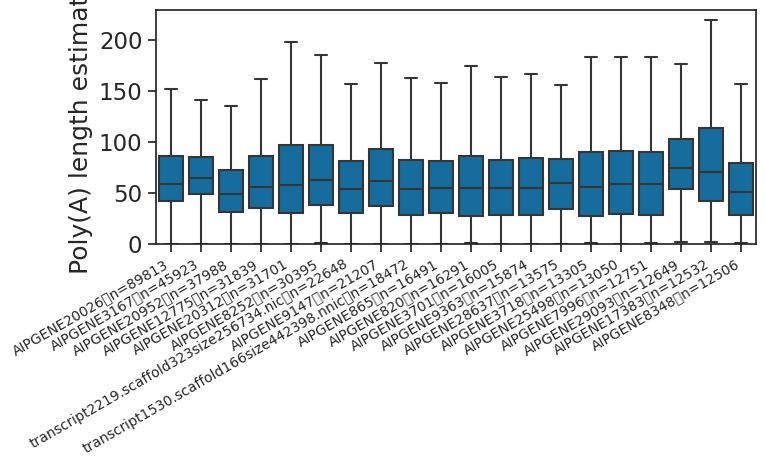

In [34]:
reads_per_contig = polya_lengths_apo.contig.value_counts()
#order = reads_per_contig[reads_per_contig >= 10000].index
order = reads_per_contig.nlargest(20).index  # draw the top 50 genes 

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    x='contig',
    y='polya_length',
    data=polya_lengths_apo,
    order=order,
    fliersize=0,
    color=pal[0],
)

ax.set_ylim(0, 230)
xticklabels = [f'{x.get_text()}\tn={reads_per_contig[x.get_text()]}' for x in ax.get_xticklabels()]
ax.set_xticklabels(xticklabels, rotation=30, ha='right', va='top', fontsize=10)
ax.set_xlabel('')
ax.set_ylabel('Poly(A) length estimate')
plt.tight_layout()
#plt.savefig('ERCC_polya_length_boxplot.svg')
plt.savefig('apo_top20_gene_polya_length_boxplot_only_6samples_isoquant.png')
plt.show()

In [35]:
polya_lengths_apo.polya_length.nlargest(10)

    readname                            
A3  9d79cc5d-642c-4a30-b7af-9b404d998688    751.55
A2  6ca19c2b-c89f-449b-9c19-38998f484311    725.96
    e6be83ad-5740-4ba4-a25f-0e9075911d35    690.22
A3  f2f3c4a5-6162-45d2-a1bb-5b13f00f0e75    686.07
    6709e7a7-9ad0-4d59-a403-cfe76ea2fdcc    679.70
    72aa9407-2f1d-4d49-a438-4537c8d1220e    671.27
A1  87891e4d-5356-4585-b066-2ef3b19da5c3    665.62
A3  11dbd03b-f18f-48c4-b298-97c1bb7bbd63    662.20
    8e418b7d-9a86-4237-87fe-88bdfbc43c2b    645.17
A2  d846ce85-628e-4fab-9754-6ff6a14492de    641.86
Name: polya_length, dtype: float64

In [36]:
apo_genes_with_longest_polya=polya_lengths_apo.sort_values(by="polya_length", ascending=False).head(20)
holo_genes_with_longest_polya=polya_lengths_holo.sort_values(by="polya_length", ascending=False).head(20)

In [37]:
np.intersect1d(apo_genes_with_longest_polya.contig, holo_genes_with_longest_polya.contig)

array([], dtype=object)

/tmp/ipykernel_279725/3583921571.py:20: UserWarning: Glyph 9 (	) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_279725/3583921571.py:22: UserWarning: Glyph 9 (	) missing from current font.
  plt.savefig('apo_top20_gene_polya_length_boxplot_only_6samples_isoquant.png')
/home/zhonh0b/miniconda3/envs/epigenetic/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


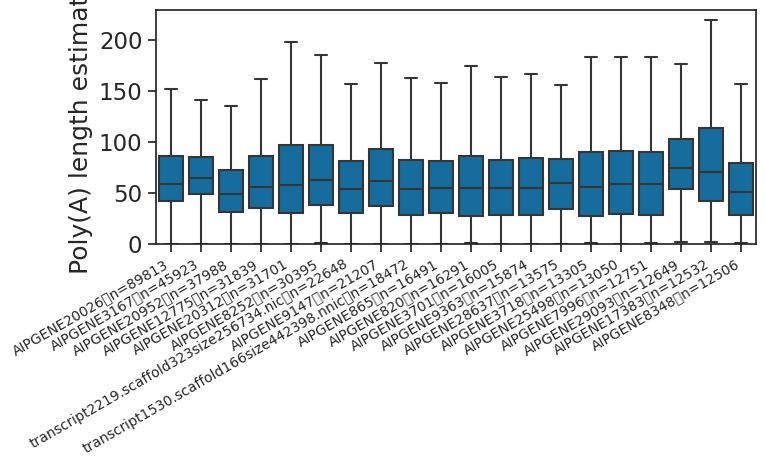

In [38]:
reads_per_contig = polya_lengths_apo.contig.value_counts()
#order = reads_per_contig[reads_per_contig >= 10000].index
order = reads_per_contig.nlargest(20).index  # draw the top 50 genes 

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    x='contig',
    y='polya_length',
    data=polya_lengths_apo,
    order=order,
    fliersize=0,
    color=pal[0],
)

ax.set_ylim(0, 230)
xticklabels = [f'{x.get_text()}\tn={reads_per_contig[x.get_text()]}' for x in ax.get_xticklabels()]
ax.set_xticklabels(xticklabels, rotation=30, ha='right', va='top', fontsize=10)
ax.set_xlabel('')
ax.set_ylabel('Poly(A) length estimate')
plt.tight_layout()
#plt.savefig('ERCC_polya_length_boxplot.svg')
plt.savefig('apo_top20_gene_polya_length_boxplot_only_6samples_isoquant.png')
plt.show()

In [39]:
reads_per_contig.nlargest(20).index

Index(['AIPGENE20026', 'AIPGENE3167', 'AIPGENE20952', 'AIPGENE12775',
       'AIPGENE20312', 'AIPGENE8252',
       'transcript2219.scaffold323size256734.nic', 'AIPGENE9147',
       'transcript1530.scaffold166size442398.nnic', 'AIPGENE865', 'AIPGENE820',
       'AIPGENE3701', 'AIPGENE9363', 'AIPGENE28637', 'AIPGENE3718',
       'AIPGENE25498', 'AIPGENE7996', 'AIPGENE29093', 'AIPGENE17383',
       'AIPGENE8348'],
      dtype='object', name='contig')

/tmp/ipykernel_279725/782887085.py:20: UserWarning: Glyph 9 (	) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_279725/782887085.py:22: UserWarning: Glyph 9 (	) missing from current font.
  plt.savefig('holo_top20_gene_polya_length_boxplot_only6samples_isoquant.png')
/home/zhonh0b/miniconda3/envs/epigenetic/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


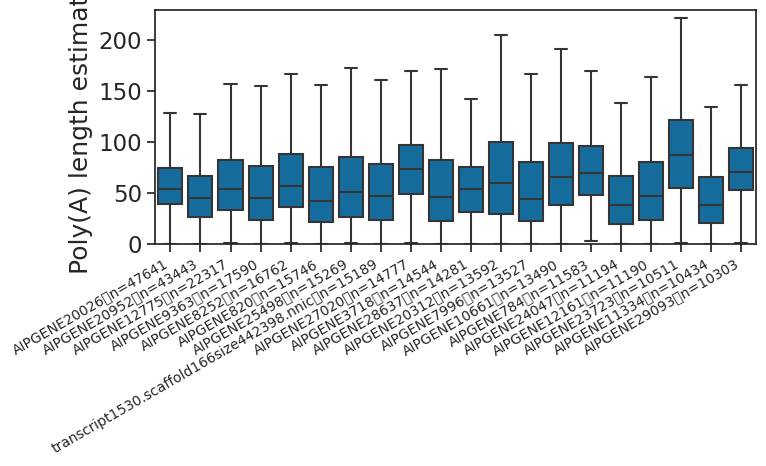

In [40]:
reads_per_contig = polya_lengths_holo.contig.value_counts()
#order = reads_per_contig[reads_per_contig >= 10000].index
order = reads_per_contig.nlargest(20).index  # draw the top 50 genes 

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    x='contig',
    y='polya_length',
    data=polya_lengths_holo,
    order=order,
    fliersize=0,
    color=pal[0],
)

ax.set_ylim(0, 230)
xticklabels = [f'{x.get_text()}\tn={reads_per_contig[x.get_text()]}' for x in ax.get_xticklabels()]
ax.set_xticklabels(xticklabels, rotation=30, ha='right', va='top', fontsize=10)
ax.set_xlabel('')
ax.set_ylabel('Poly(A) length estimate')
plt.tight_layout()
#plt.savefig('ERCC_polya_length_boxplot.svg')
plt.savefig('holo_top20_gene_polya_length_boxplot_only6samples_isoquant.png')
plt.show()

In [41]:
reads_per_contig.nlargest(20).index

Index(['AIPGENE20026', 'AIPGENE20952', 'AIPGENE12775', 'AIPGENE9363',
       'AIPGENE8252', 'AIPGENE820', 'AIPGENE25498',
       'transcript1530.scaffold166size442398.nnic', 'AIPGENE27020',
       'AIPGENE3718', 'AIPGENE28637', 'AIPGENE20312', 'AIPGENE7996',
       'AIPGENE10661', 'AIPGENE784', 'AIPGENE24047', 'AIPGENE12161',
       'AIPGENE23723', 'AIPGENE11334', 'AIPGENE29093'],
      dtype='object', name='contig')

In [42]:
np.intersect1d(polya_lengths_apo.contig.value_counts().nlargest(20).index,polya_lengths_holo.contig.value_counts().nlargest(20).index)

array(['AIPGENE12775', 'AIPGENE20026', 'AIPGENE20312', 'AIPGENE20952',
       'AIPGENE25498', 'AIPGENE28637', 'AIPGENE29093', 'AIPGENE3718',
       'AIPGENE7996', 'AIPGENE820', 'AIPGENE8252', 'AIPGENE9363',
       'transcript1530.scaffold166size442398.nnic'], dtype=object)

In [15]:
expression=pd.read_csv('/ibex/scratch/projects/c2101/aip_epitrans_analysis/isoquant/outputs/final_all_ref/OUT/OUT.transcript_model_grouped_counts.tsv',sep='\t')  # nanocount_all_results.csv
expression

,#feature_id,A1,A2,A3,A4,H1,H2,H3,H4
0,AIPGENE13048,135.0,89.0,411.0,61.0,66.0,271.0,159.0,16.0
1,AIPGENE13060,2.0,5.0,5.0,0.0,1.0,5.0,6.0,1.0
2,AIPGENE13063,18.5,14.0,59.5,11.0,8.0,36.5,23.0,2.5
3,AIPGENE13065,8.0,18.0,28.0,15.0,3.0,32.0,25.0,1.0
4,AIPGENE13072,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...
16061,AIPGENE24319,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
16062,AIPGENE7450,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
16063,AIPGENE14784,2.0,3.0,7.0,1.0,0.0,3.0,5.0,0.0
16064,AIPGENE22299,1.0,0.0,2.0,1.0,0.0,2.0,1.0,0.0


In [16]:
expression.rename(columns={'#feature_id':'transcript_name'},inplace=True)

In [17]:
expression['cpm_A1'] = expression['A1'] / expression['A1'].sum(0) * 1_000_000
expression['cpm_A2'] = expression['A2'] / expression['A2'].sum(0) * 1_000_000
expression['cpm_A3'] = expression['A3'] / expression['A3'].sum(0) * 1_000_000
expression['cpm_A4'] = expression['A4'] / expression['A4'].sum(0) * 1_000_000
expression['cpm_H1'] = expression['H1'] / expression['H1'].sum(0) * 1_000_000
expression['cpm_H2'] = expression['H2'] / expression['H2'].sum(0) * 1_000_000
expression['cpm_H3'] = expression['H3'] / expression['H3'].sum(0) * 1_000_000
expression['cpm_H4'] = expression['H4'] / expression['H4'].sum(0) * 1_000_000
expression
#vir1_pa_dists['cpm_vir1'] = vir1_pa_dists['nreads_vir1'] / vir1_pa_dists['nreads_vir1'].sum(0) * 1_000_000
#vir1_pa_dists['med_change'] = vir1_pa_dists['median_vir1'] - vir1_pa_dists['median_col0']
#vir1_pa_dists.head()

,transcript_name,A1,A2,A3,A4,H1,H2,H3,H4,cpm_A1,cpm_A2,cpm_A3,cpm_A4,cpm_H1,cpm_H2,cpm_H3,cpm_H4
0,AIPGENE13048,135.0,89.0,411.0,61.0,66.0,271.0,159.0,16.0,114.043010,84.132282,133.249850,141.376196,101.364179,93.809497,83.681665,69.580380
1,AIPGENE13060,2.0,5.0,5.0,0.0,1.0,5.0,6.0,1.0,1.689526,4.726533,1.621044,0.000000,1.535821,1.730803,3.157799,4.348774
2,AIPGENE13063,18.5,14.0,59.5,11.0,8.0,36.5,23.0,2.5,15.628116,13.234292,19.290428,25.494068,12.286567,12.634858,12.104895,10.871934
3,AIPGENE13065,8.0,18.0,28.0,15.0,3.0,32.0,25.0,1.0,6.758104,17.015518,9.077849,34.764638,4.607463,11.077136,13.157494,4.348774
4,AIPGENE13072,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.526300,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16061,AIPGENE24319,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.324209,0.000000,0.000000,0.000000,0.000000,0.000000
16062,AIPGENE7450,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.945307,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
16063,AIPGENE14784,2.0,3.0,7.0,1.0,0.0,3.0,5.0,0.0,1.689526,2.835920,2.269462,2.317643,0.000000,1.038482,2.631499,0.000000
16064,AIPGENE22299,1.0,0.0,2.0,1.0,0.0,2.0,1.0,0.0,0.844763,0.000000,0.648418,2.317643,0.000000,0.692321,0.526300,0.000000


In [18]:
expression=expression[['transcript_name','A1','A2','A3','H1','H2','H3','cpm_A1','cpm_A2','cpm_A3','cpm_H1','cpm_H2','cpm_H3']]

In [19]:
expression['cpm_apo']= expression[['cpm_A1','cpm_A2','cpm_A3']].median(axis=1)
expression['cpm_holo']= expression[['cpm_H1','cpm_H2','cpm_H3']].median(axis=1)

/tmp/ipykernel_800951/117874221.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  expression['cpm_apo']= expression[['cpm_A1','cpm_A2','cpm_A3']].median(axis=1)
/tmp/ipykernel_800951/117874221.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  expression['cpm_holo']= expression[['cpm_H1','cpm_H2','cpm_H3']].median(axis=1)


In [50]:
expression

,transcript_name,A1,A2,A3,H1,H2,H3,cpm_A1,cpm_A2,cpm_A3,cpm_H1,cpm_H2,cpm_H3,cpm_apo,cpm_holo
0,AIPGENE13048,135.0,89.0,411.0,66.0,271.0,159.0,114.043010,84.132282,133.249850,101.364179,93.809497,83.681665,114.043010,93.809497
1,AIPGENE13060,2.0,5.0,5.0,1.0,5.0,6.0,1.689526,4.726533,1.621044,1.535821,1.730803,3.157799,1.689526,1.730803
2,AIPGENE13063,18.5,14.0,59.5,8.0,36.5,23.0,15.628116,13.234292,19.290428,12.286567,12.634858,12.104895,15.628116,12.286567
3,AIPGENE13065,8.0,18.0,28.0,3.0,32.0,25.0,6.758104,17.015518,9.077849,4.607463,11.077136,13.157494,9.077849,11.077136
4,AIPGENE13072,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.526300,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16061,AIPGENE24319,0.0,0.0,1.0,0.0,0.0,0.0,0.000000,0.000000,0.324209,0.000000,0.000000,0.000000,0.000000,0.000000
16062,AIPGENE7450,0.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.945307,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
16063,AIPGENE14784,2.0,3.0,7.0,0.0,3.0,5.0,1.689526,2.835920,2.269462,0.000000,1.038482,2.631499,2.269462,1.038482
16064,AIPGENE22299,1.0,0.0,2.0,0.0,2.0,1.0,0.844763,0.000000,0.648418,0.000000,0.692321,0.526300,0.648418,0.526300


In [20]:
polya_lengths_apo

contig  \
   readname                                                                          
A3 bdc4b5f0-296f-4511-b141-b7df2a27155a  transcript2302.scaffold1000size19988.nnic   
   38fddfe7-91ee-47a6-84ad-33b5cfe14a25                               AIPGENE19183   
   298ec2e7-37e6-46d1-888e-24c769d4bbd3  transcript2302.scaffold1000size19988.nnic   
   df32de9f-90f8-4545-8b17-f59c2928d573  transcript2302.scaffold1000size19988.nnic   
   bfb37d15-3116-43f0-adfe-4589b8834695  transcript2302.scaffold1000size19988.nnic   
...                                                                            ...   
A1 727321e7-1258-433a-8441-4125d4c8fabf                                AIPGENE4012   
   bea50c5f-8076-485d-8c95-75c0cfb64a57                                AIPGENE4012   
   7c403e21-4a49-4d74-93fe-6b7b89ad995c                                AIPGENE4012   
   c0332f2b-ef4a-4917-b637-fa309668dc65                                AIPGENE3936   
   e1d46fbe-dc61-4506-b3ae-b0ecda512c4f                                AIPGENE3936   

                                         position  polya_length qc_tag sample  
   readname                                                                    
A3 bdc4b5f0-296f-4511-b141-b7df2a27155a       443         22.17   PASS     A3  
   38fddfe7-91ee-47a6-84ad-33b5cfe14a25       150         51.07   PASS     A3  
   298ec2e7-37e6-46d1-888e-24c769d4bbd3         8         21.00   PASS     A3  
   df32de9f-90f8-4545-8b17-f59c2928d573       401        167.89   PASS     A3  
   bfb37d15-3116-43f0-adfe-4589b8834695        60        129.64   PASS     A3  
...                                           ...           ...    ...    ...  
A1 727321e7-1258-433a-8441-4125d4c8fabf      1441         12.09   PASS     A1  
   bea50c5f-8076-485d-8c95-75c0cfb64a57      1407         30.92   PASS     A1  
   7c403e21-4a49-4d74-93fe-6b7b89ad995c       124        114.96   PASS     A1  
   c0332f2b-ef4a-4917-b637-fa309668dc65      1797         34.26   PASS     A1  
   e1d46fbe-dc61-4506-b3ae-b0ecda512c4f      2670        209.61   PASS     A1  

[4417395 rows x 5 columns]

In [52]:
polya_lengths_apo['polya_length'].max()

751.55

In [53]:
polya_lengths_holo['polya_length'].max()

810.05

In [54]:
polya_lengths_holo['polya_length'].min()

0.0

In [55]:
polya_lengths_apo['polya_length'].min()

0.0

In [21]:
# because the polyA length usually ranges between 20-250 nt, we can filter out the outliers that are likely due to technical artifacts. This will help us get a more accurate picture of the typical polyA tail lengths in our samples.
polya_lengths_apo=polya_lengths_apo[(polya_lengths_apo['polya_length']>10) & (polya_lengths_apo['polya_length']<250)]
polya_lengths_holo=polya_lengths_holo[(polya_lengths_holo['polya_length']>10) & (polya_lengths_holo['polya_length']<250)]

In [22]:
polya_avg_length_apo = polya_lengths_apo.groupby('contig')['polya_length'].median().reset_index()
polya_avg_length_holo = polya_lengths_holo.groupby('contig')['polya_length'].median().reset_index()

In [23]:
polya_avg_length_apo

,contig,polya_length
0,AIPGENE10000,68.700
1,AIPGENE10002,85.560
2,AIPGENE10004,80.210
3,AIPGENE10006,97.980
4,AIPGENE10007,73.770
...,...,...
28480,transcript998.scaffold54size781874.nic,107.520
28481,transcript998.scaffold71size717949.nic,84.380
28482,transcript998.scaffold92size630311.nnic,79.840
28483,transcript999.scaffold71size717949.nnic,79.020


In [24]:
from scipy.stats import mannwhitneyu
import numpy as np
import matplotlib.pyplot as plt

polya_lengths_apo_values = polya_avg_length_apo["polya_length"].dropna()
polya_lengths_holo_values = polya_avg_length_holo["polya_length"].dropna()

stat, p_value = mannwhitneyu(
    polya_lengths_apo_values,
    polya_lengths_holo_values,
    alternative="two-sided"
)

print("Mann–Whitney U test p-value:", p_value)

Mann–Whitney U test p-value: 1.0628683659423997e-140


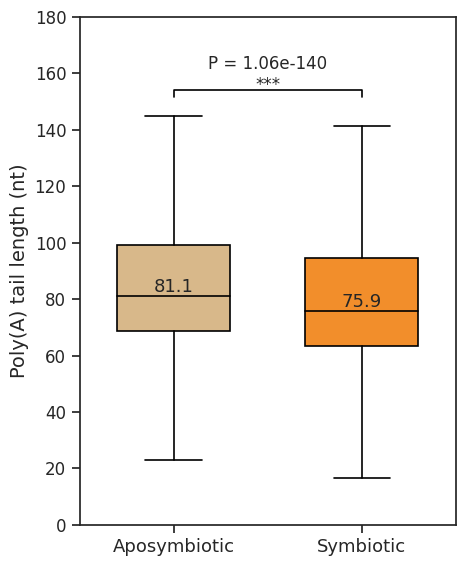

In [32]:
polya_lengths_apo_values = polya_avg_length_apo["polya_length"]
polya_lengths_holo_values = polya_avg_length_holo["polya_length"]

data = [
    polya_lengths_apo_values.dropna(),
    polya_lengths_holo_values.dropna()
]
#colors = ["#C49A6C", "#F28E2B"]
colors = ["#D8B88A", "#F28E2B"]

medians = [np.median(x) for x in data]
# Statistical test
stat, p_value = mannwhitneyu(
    polya_lengths_apo_values,
    polya_lengths_holo_values,
    alternative="two-sided"
)

def p_to_star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

p_label = p_to_star(p_value)

plt.figure(figsize=(5, 6))

labels = ["Aposymbiotic", "Symbiotic"]
bp = plt.boxplot(
    data,
    labels=labels,
    patch_artist=True,
    showfliers=False,
    widths=0.6
)

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor("black")
    patch.set_linewidth(1.2)

# color other elements
for element in ["whiskers", "caps", "medians"]:
    for item in bp[element]:
        item.set_color("black")
        item.set_linewidth(1.2)

for i, median in enumerate(medians, start=1):
    plt.text(
        i, median,
        f"{median:.1f}",
        ha="center",
        va="bottom",
        fontsize=13,
        #fontweight="bold"
    )

# Add statistical comparison line
y_max_visible = max(
    max(whisker.get_ydata()) for whisker in bp["whiskers"]
)

y_min_visible = min(
    min(whisker.get_ydata()) for whisker in bp["whiskers"]
)

y_range = y_max_visible - y_min_visible

line_y = y_max_visible + 0.05 * y_range
text_y = y_max_visible + 0.06 * y_range

x1, x2 = 1, 2

plt.plot(
    [x1, x1, x2, x2],
    [line_y, line_y + 0.02 * y_range, line_y + 0.02 * y_range, line_y],
    color="black",
    linewidth=1.2
)

plt.text(
    (x1 + x2) / 2,
    text_y,
    f"P = {p_value:.2e}\n{p_label}",
    ha="center",
    va="bottom",
    fontsize=12
)
plt.ylim(0, 180)
plt.ylabel("Poly(A) tail length (nt)", fontsize=14)
plt.xticks(fontsize=13)
plt.yticks(fontsize=12)

plt.tight_layout()

plt.savefig("polya_length_filtered_boxplot_by_transcripts_colored_isoquant.png", dpi=300, bbox_inches="tight")
plt.show()

In [33]:
# sample level comparison 
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu, ttest_ind

apo_df = polya_lengths_apo.copy()
holo_df = polya_lengths_holo.copy()

apo_df["condition"] = "Aposymbiotic"
holo_df["condition"] = "Symbiotic"

polya_all = pd.concat([apo_df, holo_df], ignore_index=True)

sample_summary = (
    polya_all
    .groupby(["condition", "sample"])
    .agg(
        median_polya_length=("polya_length", "median"),
        mean_polya_length=("polya_length", "mean"),
        n_reads=("polya_length", "count"),
        n_contigs=("contig", "nunique")
    )
    .reset_index()
)

sample_summary

,condition,sample,median_polya_length,mean_polya_length,n_reads,n_contigs
0,Aposymbiotic,A1,66.85,76.397228,1010351,24039
1,Aposymbiotic,A2,72.97,82.148317,916161,23883
2,Aposymbiotic,A3,67.26,76.387974,2351015,24316
3,Symbiotic,H1,57.77,67.156443,503899,21254
4,Symbiotic,H2,66.00,76.014331,1510482,18057
5,Symbiotic,H3,65.71,76.031841,1518036,25873


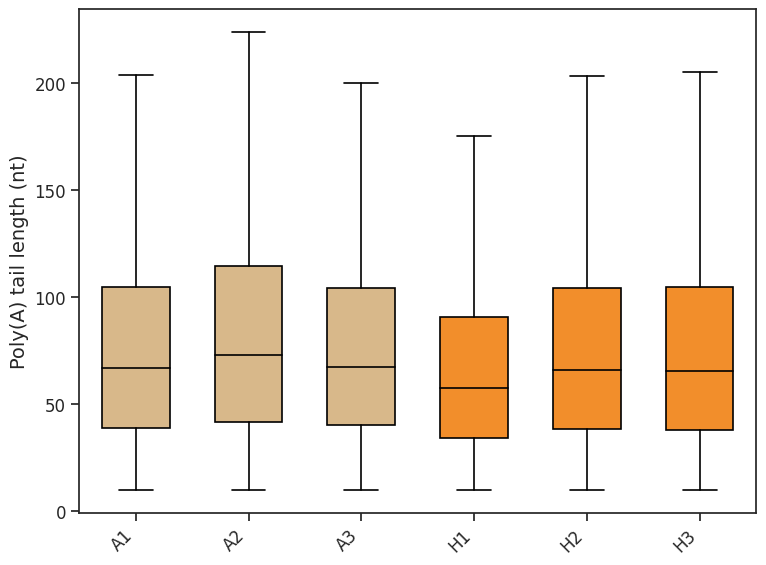

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

apo_df = polya_lengths_apo.copy()
holo_df = polya_lengths_holo.copy()

apo_df["condition"] = "Aposymbiotic"
holo_df["condition"] = "Symbiotic"

polya_all = pd.concat([apo_df, holo_df], ignore_index=True)

# Optional: keep only Nanopolish PASS reads
polya_all = polya_all[polya_all["qc_tag"] == "PASS"].copy()

# Order samples: apo first, then sym
sample_order = (
    polya_all
    .drop_duplicates(["condition", "sample"])
    .sort_values(["condition", "sample"])
    ["sample"]
    .tolist()
)

data = [
    polya_all.loc[polya_all["sample"] == sample, "polya_length"].dropna()
    for sample in sample_order
]

sample_conditions = [
    polya_all.loc[polya_all["sample"] == sample, "condition"].iloc[0]
    for sample in sample_order
]

colors = [
    "#D8B88A" if cond == "Aposymbiotic" else "#F28E2B"
    for cond in sample_conditions
]

plt.figure(figsize=(8, 6))

bp = plt.boxplot(
    data,
    labels=sample_order,
    patch_artist=True,
    showfliers=False,
    widths=0.6
)

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor("black")
    patch.set_linewidth(1.2)

for element in ["whiskers", "caps", "medians"]:
    for item in bp[element]:
        item.set_color("black")
        item.set_linewidth(1.2)

plt.ylabel("Poly(A) tail length (nt)", fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()

plt.savefig(
    "polya_length_boxplot_by_sample_no_stat_filtered_isoquant.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [40]:
expression.head()

,transcript_name,A1,A2,A3,H1,H2,H3,cpm_A1,cpm_A2,cpm_A3,cpm_H1,cpm_H2,cpm_H3,cpm_apo,cpm_holo
0,AIPGENE13048,135.0,89.0,411.0,66.0,271.0,159.0,114.043010,84.132282,133.249850,101.364179,93.809497,83.681665,114.043010,93.809497
1,AIPGENE13060,2.0,5.0,5.0,1.0,5.0,6.0,1.689526,4.726533,1.621044,1.535821,1.730803,3.157799,1.689526,1.730803
2,AIPGENE13063,18.5,14.0,59.5,8.0,36.5,23.0,15.628116,13.234292,19.290428,12.286567,12.634858,12.104895,15.628116,12.286567
3,AIPGENE13065,8.0,18.0,28.0,3.0,32.0,25.0,6.758104,17.015518,9.077849,4.607463,11.077136,13.157494,9.077849,11.077136
4,AIPGENE13072,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.526300,0.000000,0.000000


In [73]:
expression['transcript_name']=expression['transcript_name'].str.replace('_gene', '', regex=True)

/tmp/ipykernel_279725/2782849565.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  expression['transcript_name']=expression['transcript_name'].str.replace('_gene', '', regex=True)


In [41]:
# Step 1: Identify common genes
common_genes_apo = set(expression['transcript_name']).intersection(polya_avg_length_apo['contig'])

# Step 2: Subset and order the rows
expression_common_apo = expression[expression['transcript_name'].isin(common_genes_apo)].copy()
polya_avg_length_apo_common = polya_avg_length_apo[polya_avg_length_apo['contig'].isin(common_genes_apo)].copy()

# Step 1: Create a mapping
common_col_mapping = {val: idx for idx, val in enumerate(polya_avg_length_apo_common['contig'])}

# Step 2: Apply the mapping to df2
expression_common_apo['order'] = expression_common_apo['transcript_name'].map(common_col_mapping)

# Step 3: Sort df2 based on the new order
expression_common_apo = expression_common_apo.sort_values(by='order').drop(columns='order')

# Reset the index if needed
expression_common_apo = expression_common_apo.reset_index(drop=True)
expression_common_apo

,transcript_name,A1,A2,A3,H1,H2,H3,cpm_A1,cpm_A2,cpm_A3,cpm_H1,cpm_H2,cpm_H3,cpm_apo,cpm_holo
0,AIPGENE10002,110.0,57.00,128.0,23.0,159.00,123.00,92.923934,53.882473,41.498737,35.323881,55.039520,64.734873,53.882473,55.039520
1,AIPGENE10004,13.0,14.00,36.0,11.0,31.00,23.00,10.981920,13.234292,11.671520,16.894030,10.730976,12.104895,11.671520,12.104895
2,AIPGENE10007,46.0,45.00,137.0,36.0,136.00,98.00,38.859100,42.538794,44.416617,55.289552,47.077829,51.577378,42.538794,51.577378
3,AIPGENE1001,7.0,10.00,24.0,3.0,19.00,10.00,5.913341,9.453065,7.781013,4.607463,6.577050,5.262998,7.781013,5.262998
4,AIPGENE10010,85.0,82.00,200.0,31.0,165.00,157.00,71.804858,77.515136,64.841776,47.610448,57.116483,82.629065,71.804858,57.116483
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15274,transcript998.scaffold54size781874.nic,39.0,137.00,82.0,20.5,144.50,78.50,32.945759,129.506996,26.585128,31.484328,50.020193,41.314533,32.945759,41.314533
15275,transcript998.scaffold71size717949.nic,4.5,6.50,22.0,5.0,16.50,9.50,3.801434,6.144493,7.132595,7.679104,5.711648,4.999848,6.144493,5.711648
15276,transcript998.scaffold92size630311.nnic,10.5,8.00,38.0,5.5,37.00,18.50,8.870012,7.562452,12.319938,8.447015,12.807939,9.736546,8.870012,9.736546
15277,transcript999.scaffold71size717949.nnic,21.0,8.33,56.0,13.0,47.67,48.67,17.740024,7.874403,18.155697,19.965672,16.501471,25.615010,17.740024,19.965672


In [42]:
expression_common_apo_6_samples=expression_common_apo[['transcript_name', 'A1', 'A2', 'A3', 'H1', 'H2', 'H3','cpm_A1', 'cpm_A2', 'cpm_A3', 'cpm_H1', 'cpm_H2', 'cpm_H3']]
expression_common_apo_6_samples['cpm_holo']= expression[['cpm_H1','cpm_H2','cpm_H3']].median(axis=1)
expression_common_apo_6_samples['cpm_apo']= expression[['cpm_A1','cpm_A2','cpm_A3']].median(axis=1)

/tmp/ipykernel_800951/2897002071.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  expression_common_apo_6_samples['cpm_holo']= expression[['cpm_H1','cpm_H2','cpm_H3']].median(axis=1)


In [43]:
polya_avg_length_apo_common

,contig,polya_length
1,AIPGENE10002,85.560
2,AIPGENE10004,80.210
4,AIPGENE10007,73.770
7,AIPGENE1001,104.940
8,AIPGENE10010,115.960
...,...,...
28480,transcript998.scaffold54size781874.nic,107.520
28481,transcript998.scaffold71size717949.nic,84.380
28482,transcript998.scaffold92size630311.nnic,79.840
28483,transcript999.scaffold71size717949.nnic,79.020


In [44]:
expression_common_apo

,transcript_name,A1,A2,A3,H1,H2,H3,cpm_A1,cpm_A2,cpm_A3,cpm_H1,cpm_H2,cpm_H3,cpm_apo,cpm_holo
0,AIPGENE10002,110.0,57.00,128.0,23.0,159.00,123.00,92.923934,53.882473,41.498737,35.323881,55.039520,64.734873,53.882473,55.039520
1,AIPGENE10004,13.0,14.00,36.0,11.0,31.00,23.00,10.981920,13.234292,11.671520,16.894030,10.730976,12.104895,11.671520,12.104895
2,AIPGENE10007,46.0,45.00,137.0,36.0,136.00,98.00,38.859100,42.538794,44.416617,55.289552,47.077829,51.577378,42.538794,51.577378
3,AIPGENE1001,7.0,10.00,24.0,3.0,19.00,10.00,5.913341,9.453065,7.781013,4.607463,6.577050,5.262998,7.781013,5.262998
4,AIPGENE10010,85.0,82.00,200.0,31.0,165.00,157.00,71.804858,77.515136,64.841776,47.610448,57.116483,82.629065,71.804858,57.116483
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15274,transcript998.scaffold54size781874.nic,39.0,137.00,82.0,20.5,144.50,78.50,32.945759,129.506996,26.585128,31.484328,50.020193,41.314533,32.945759,41.314533
15275,transcript998.scaffold71size717949.nic,4.5,6.50,22.0,5.0,16.50,9.50,3.801434,6.144493,7.132595,7.679104,5.711648,4.999848,6.144493,5.711648
15276,transcript998.scaffold92size630311.nnic,10.5,8.00,38.0,5.5,37.00,18.50,8.870012,7.562452,12.319938,8.447015,12.807939,9.736546,8.870012,9.736546
15277,transcript999.scaffold71size717949.nnic,21.0,8.33,56.0,13.0,47.67,48.67,17.740024,7.874403,18.155697,19.965672,16.501471,25.615010,17.740024,19.965672


In [45]:
expression_common_apo.columns

Index(['transcript_name', 'A1', 'A2', 'A3', 'H1', 'H2', 'H3', 'cpm_A1',
       'cpm_A2', 'cpm_A3', 'cpm_H1', 'cpm_H2', 'cpm_H3', 'cpm_apo',
       'cpm_holo'],
      dtype='object')

In [46]:
# Step 1: Identify common genes
common_genes_holo = set(expression['transcript_name']).intersection(polya_avg_length_holo['contig'])

# Step 2: Subset and order the rows
expression_common_holo = expression[expression['transcript_name'].isin(common_genes_holo)].copy()
polya_avg_length_holo_common = polya_avg_length_holo[polya_avg_length_holo['contig'].isin(common_genes_holo)].copy()

# Step 1: Create a mapping
common_col_mapping = {val: idx for idx, val in enumerate(polya_avg_length_holo_common['contig'])}

# Step 2: Apply the mapping to df2
expression_common_holo['order'] = expression_common_holo['transcript_name'].map(common_col_mapping)

# Step 3: Sort df2 based on the new order
expression_common_holo = expression_common_holo.sort_values(by='order').drop(columns='order')

# Reset the index if needed
expression_common_holo = expression_common_holo.reset_index(drop=True)

In [47]:
expression_common_holo

,transcript_name,A1,A2,A3,H1,H2,H3,cpm_A1,cpm_A2,cpm_A3,cpm_H1,cpm_H2,cpm_H3,cpm_apo,cpm_holo
0,AIPGENE10002,110.0,57.00,128.0,23.0,159.00,123.00,92.923934,53.882473,41.498737,35.323881,55.039520,64.734873,53.882473,55.039520
1,AIPGENE10003,1.0,0.00,0.0,1.0,5.00,0.00,0.844763,0.000000,0.000000,1.535821,1.730803,0.000000,0.000000,1.535821
2,AIPGENE10004,13.0,14.00,36.0,11.0,31.00,23.00,10.981920,13.234292,11.671520,16.894030,10.730976,12.104895,11.671520,12.104895
3,AIPGENE10007,46.0,45.00,137.0,36.0,136.00,98.00,38.859100,42.538794,44.416617,55.289552,47.077829,51.577378,42.538794,51.577378
4,AIPGENE1001,7.0,10.00,24.0,3.0,19.00,10.00,5.913341,9.453065,7.781013,4.607463,6.577050,5.262998,7.781013,5.262998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15111,transcript998.scaffold54size781874.nic,39.0,137.00,82.0,20.5,144.50,78.50,32.945759,129.506996,26.585128,31.484328,50.020193,41.314533,32.945759,41.314533
15112,transcript998.scaffold71size717949.nic,4.5,6.50,22.0,5.0,16.50,9.50,3.801434,6.144493,7.132595,7.679104,5.711648,4.999848,6.144493,5.711648
15113,transcript998.scaffold92size630311.nnic,10.5,8.00,38.0,5.5,37.00,18.50,8.870012,7.562452,12.319938,8.447015,12.807939,9.736546,8.870012,9.736546
15114,transcript999.scaffold71size717949.nnic,21.0,8.33,56.0,13.0,47.67,48.67,17.740024,7.874403,18.155697,19.965672,16.501471,25.615010,17.740024,19.965672


In [48]:
polya_avg_length_holo_common

,contig,polya_length
2,AIPGENE10002,72.78
3,AIPGENE10003,70.38
4,AIPGENE10004,55.63
6,AIPGENE10007,80.56
8,AIPGENE1001,85.39
...,...,...
27856,transcript998.scaffold54size781874.nic,84.82
27857,transcript998.scaffold71size717949.nic,197.54
27858,transcript998.scaffold92size630311.nnic,59.61
27859,transcript999.scaffold71size717949.nnic,71.79


In [49]:
expression_common_holo_6_samples=expression_common_holo[['transcript_name', 'A1', 'A2', 'A3', 'H1', 'H2', 'H3','cpm_A1', 'cpm_A2', 'cpm_A3', 'cpm_H1', 'cpm_H2', 'cpm_H3']]
expression_common_holo_6_samples['cpm_holo']= expression[['cpm_H1','cpm_H2','cpm_H3']].median(axis=1)
expression_common_holo_6_samples['cpm_apo']= expression[['cpm_A1','cpm_A2','cpm_A3']].median(axis=1)

/tmp/ipykernel_800951/387320181.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  expression_common_holo_6_samples['cpm_holo']= expression[['cpm_H1','cpm_H2','cpm_H3']].median(axis=1)


In [50]:
expression_common_holo_6_samples

,transcript_name,A1,A2,A3,H1,H2,H3,cpm_A1,cpm_A2,cpm_A3,cpm_H1,cpm_H2,cpm_H3,cpm_holo,cpm_apo
0,AIPGENE10002,110.0,57.00,128.0,23.0,159.00,123.00,92.923934,53.882473,41.498737,35.323881,55.039520,64.734873,93.809497,114.043010
1,AIPGENE10003,1.0,0.00,0.0,1.0,5.00,0.00,0.844763,0.000000,0.000000,1.535821,1.730803,0.000000,1.730803,1.689526
2,AIPGENE10004,13.0,14.00,36.0,11.0,31.00,23.00,10.981920,13.234292,11.671520,16.894030,10.730976,12.104895,12.286567,15.628116
3,AIPGENE10007,46.0,45.00,137.0,36.0,136.00,98.00,38.859100,42.538794,44.416617,55.289552,47.077829,51.577378,11.077136,9.077849
4,AIPGENE1001,7.0,10.00,24.0,3.0,19.00,10.00,5.913341,9.453065,7.781013,4.607463,6.577050,5.262998,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15111,transcript998.scaffold54size781874.nic,39.0,137.00,82.0,20.5,144.50,78.50,32.945759,129.506996,26.585128,31.484328,50.020193,41.314533,5.173527,4.887235
15112,transcript998.scaffold71size717949.nic,4.5,6.50,22.0,5.0,16.50,9.50,3.801434,6.144493,7.132595,7.679104,5.711648,4.999848,3.071642,0.486313
15113,transcript998.scaffold92size630311.nnic,10.5,8.00,38.0,5.5,37.00,18.50,8.870012,7.562452,12.319938,8.447015,12.807939,9.736546,7.961692,1.458940
15114,transcript999.scaffold71size717949.nnic,21.0,8.33,56.0,13.0,47.67,48.67,17.740024,7.874403,18.155697,19.965672,16.501471,25.615010,1112.071433,1203.139160


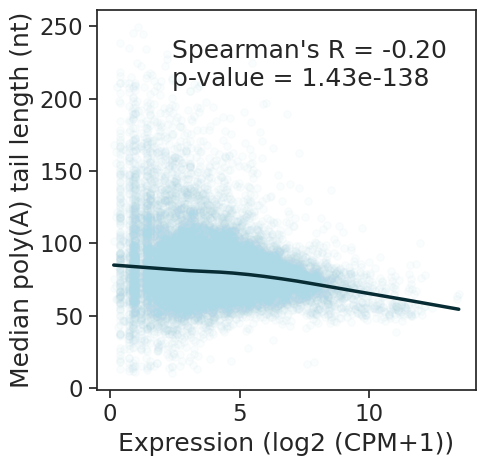

In [84]:
fig, ax = plt.subplots(figsize=(5.2, 5))
plt.tight_layout()

merge_apo_df = pd.merge(
    expression_common_apo,
    polya_avg_length_apo_common,
    left_on='transcript_name',
    right_on='contig'
)
plot_df = merge_apo_df[merge_apo_df["cpm_apo"] > 0].copy()
sns.regplot(
    x=np.log2(plot_df["cpm_apo"]+1),
    y=plot_df["polya_length"],
    scatter_kws={'alpha': 0.05, 'rasterized': True,'color':'lightblue','s':28},
    line_kws={'color': "#072C34",'linewidth': 2.5},
    lowess=True, ax=ax
)

ax.set_xlabel('Expression (log2 (CPM+1))')
ax.set_ylabel('Median poly(A) tail length (nt)')

rho, p = stats.spearmanr(plot_df["cpm_apo"], plot_df["polya_length"])

ax.annotate(
        f"Spearman's R = {rho:.2f}\np-value = {p:.2e}",
        xy=(0.2, 0.80),
    #xy=(0.67, 0.9), text=f'ρ={rho:.2f}', 
    xycoords='axes fraction') #xy=(0.67, 0.9)
#ax.axhline(y=rho, color='red', linestyle='--', label=f'ρ={rho:.2f}')

plt.tight_layout()
plt.savefig('median_polya_length_vs_median_expression_apo_isoquant.png',dpi=300, transparent=True)
plt.show()

In [85]:
plot_df

,transcript_name,A1,A2,A3,H1,H2,H3,cpm_A1,cpm_A2,cpm_A3,cpm_H1,cpm_H2,cpm_H3,cpm_apo,cpm_holo,contig,polya_length
0,AIPGENE10002,110.0,57.00,128.0,23.0,159.00,123.00,92.923934,53.882473,41.498737,35.323881,55.039520,64.734873,53.882473,55.039520,AIPGENE10002,85.560
1,AIPGENE10004,13.0,14.00,36.0,11.0,31.00,23.00,10.981920,13.234292,11.671520,16.894030,10.730976,12.104895,11.671520,12.104895,AIPGENE10004,80.210
2,AIPGENE10007,46.0,45.00,137.0,36.0,136.00,98.00,38.859100,42.538794,44.416617,55.289552,47.077829,51.577378,42.538794,51.577378,AIPGENE10007,73.770
3,AIPGENE1001,7.0,10.00,24.0,3.0,19.00,10.00,5.913341,9.453065,7.781013,4.607463,6.577050,5.262998,7.781013,5.262998,AIPGENE1001,104.940
4,AIPGENE10010,85.0,82.00,200.0,31.0,165.00,157.00,71.804858,77.515136,64.841776,47.610448,57.116483,82.629065,71.804858,57.116483,AIPGENE10010,115.960
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15274,transcript998.scaffold54size781874.nic,39.0,137.00,82.0,20.5,144.50,78.50,32.945759,129.506996,26.585128,31.484328,50.020193,41.314533,32.945759,41.314533,transcript998.scaffold54size781874.nic,107.520
15275,transcript998.scaffold71size717949.nic,4.5,6.50,22.0,5.0,16.50,9.50,3.801434,6.144493,7.132595,7.679104,5.711648,4.999848,6.144493,5.711648,transcript998.scaffold71size717949.nic,84.380
15276,transcript998.scaffold92size630311.nnic,10.5,8.00,38.0,5.5,37.00,18.50,8.870012,7.562452,12.319938,8.447015,12.807939,9.736546,8.870012,9.736546,transcript998.scaffold92size630311.nnic,79.840
15277,transcript999.scaffold71size717949.nnic,21.0,8.33,56.0,13.0,47.67,48.67,17.740024,7.874403,18.155697,19.965672,16.501471,25.615010,17.740024,19.965672,transcript999.scaffold71size717949.nnic,79.020


In [86]:
print(rho, p)

-0.2038668871180006 1.4302143234654196e-138


In [87]:
boot_res = []

s = plot_df[['cpm_apo','polya_length']]  #pd.concat([expression_common_apo['cpm_apo'], polya_avg_length_apo_common['polya_length']],axis=1)
n = len(s)

for _ in range(10_000):
    samp = s.sample(n=n, replace=True)
    boot_res.append(stats.spearmanr(samp['cpm_apo'], samp['polya_length'])[0])

In [88]:
s

,cpm_apo,polya_length
0,53.882473,85.560
1,11.671520,80.210
2,42.538794,73.770
3,7.781013,104.940
4,71.804858,115.960
...,...,...
15274,32.945759,107.520
15275,6.144493,84.380
15276,8.870012,79.840
15277,17.740024,79.020


In [89]:
range(10_000)

range(0, 10000)

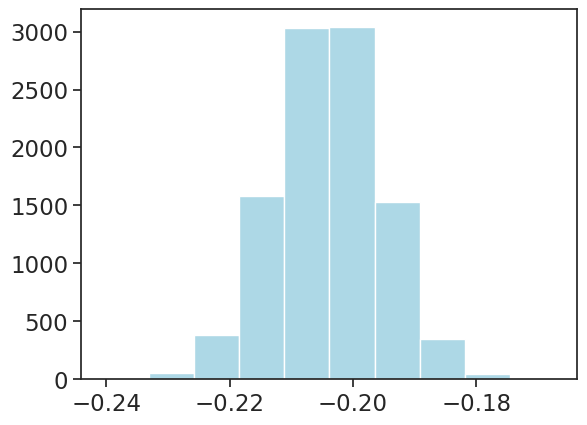

In [90]:
plt.hist(boot_res,color='lightblue')
plt.savefig('spearman_bootstrap_distribution_apo_isoquant.png',dpi=300, transparent=True)
plt.show()

In [91]:
np.percentile(boot_res, (2.5, 97.5))

array([-0.22063973, -0.18711351])

In [92]:
expression_common_apo

,transcript_name,A1,A2,A3,H1,H2,H3,cpm_A1,cpm_A2,cpm_A3,cpm_H1,cpm_H2,cpm_H3,cpm_apo,cpm_holo
0,AIPGENE10002,110.0,57.00,128.0,23.0,159.00,123.00,92.923934,53.882473,41.498737,35.323881,55.039520,64.734873,53.882473,55.039520
1,AIPGENE10004,13.0,14.00,36.0,11.0,31.00,23.00,10.981920,13.234292,11.671520,16.894030,10.730976,12.104895,11.671520,12.104895
2,AIPGENE10007,46.0,45.00,137.0,36.0,136.00,98.00,38.859100,42.538794,44.416617,55.289552,47.077829,51.577378,42.538794,51.577378
3,AIPGENE1001,7.0,10.00,24.0,3.0,19.00,10.00,5.913341,9.453065,7.781013,4.607463,6.577050,5.262998,7.781013,5.262998
4,AIPGENE10010,85.0,82.00,200.0,31.0,165.00,157.00,71.804858,77.515136,64.841776,47.610448,57.116483,82.629065,71.804858,57.116483
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15274,transcript998.scaffold54size781874.nic,39.0,137.00,82.0,20.5,144.50,78.50,32.945759,129.506996,26.585128,31.484328,50.020193,41.314533,32.945759,41.314533
15275,transcript998.scaffold71size717949.nic,4.5,6.50,22.0,5.0,16.50,9.50,3.801434,6.144493,7.132595,7.679104,5.711648,4.999848,6.144493,5.711648
15276,transcript998.scaffold92size630311.nnic,10.5,8.00,38.0,5.5,37.00,18.50,8.870012,7.562452,12.319938,8.447015,12.807939,9.736546,8.870012,9.736546
15277,transcript999.scaffold71size717949.nnic,21.0,8.33,56.0,13.0,47.67,48.67,17.740024,7.874403,18.155697,19.965672,16.501471,25.615010,17.740024,19.965672


In [93]:
expression_common_apo_6_samples['cpm_apo']= expression_common_apo_6_samples[['cpm_A1','cpm_A2','cpm_A3']].median(axis=1)
expression_common_apo_6_samples['cpm_holo']= expression_common_apo_6_samples[['cpm_H1','cpm_H2','cpm_H3']].median(axis=1)
expression_common_apo_6_samples

,transcript_name,A1,A2,A3,H1,H2,H3,cpm_A1,cpm_A2,cpm_A3,cpm_H1,cpm_H2,cpm_H3,cpm_holo,cpm_apo
0,AIPGENE10002,110.0,57.00,128.0,23.0,159.00,123.00,92.923934,53.882473,41.498737,35.323881,55.039520,64.734873,55.039520,53.882473
1,AIPGENE10004,13.0,14.00,36.0,11.0,31.00,23.00,10.981920,13.234292,11.671520,16.894030,10.730976,12.104895,12.104895,11.671520
2,AIPGENE10007,46.0,45.00,137.0,36.0,136.00,98.00,38.859100,42.538794,44.416617,55.289552,47.077829,51.577378,51.577378,42.538794
3,AIPGENE1001,7.0,10.00,24.0,3.0,19.00,10.00,5.913341,9.453065,7.781013,4.607463,6.577050,5.262998,5.262998,7.781013
4,AIPGENE10010,85.0,82.00,200.0,31.0,165.00,157.00,71.804858,77.515136,64.841776,47.610448,57.116483,82.629065,57.116483,71.804858
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15274,transcript998.scaffold54size781874.nic,39.0,137.00,82.0,20.5,144.50,78.50,32.945759,129.506996,26.585128,31.484328,50.020193,41.314533,41.314533,32.945759
15275,transcript998.scaffold71size717949.nic,4.5,6.50,22.0,5.0,16.50,9.50,3.801434,6.144493,7.132595,7.679104,5.711648,4.999848,5.711648,6.144493
15276,transcript998.scaffold92size630311.nnic,10.5,8.00,38.0,5.5,37.00,18.50,8.870012,7.562452,12.319938,8.447015,12.807939,9.736546,9.736546,8.870012
15277,transcript999.scaffold71size717949.nnic,21.0,8.33,56.0,13.0,47.67,48.67,17.740024,7.874403,18.155697,19.965672,16.501471,25.615010,19.965672,17.740024


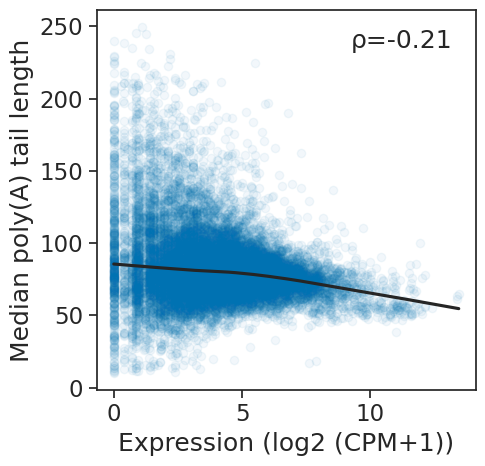

In [94]:
fig, ax = plt.subplots(figsize=(5.2, 5))
plt.tight_layout()

sns.regplot(
    x=np.log2(expression_common_apo_6_samples.cpm_apo+1),
    y=polya_avg_length_apo_common.polya_length,
    scatter_kws={'alpha': 0.05, 'rasterized': True},
    line_kws={'color': '#252525'},
    lowess=True, ax=ax
)


ax.set_xlabel('Expression (log2 (CPM+1))')
ax.set_ylabel('Median poly(A) tail length')

rho, p = stats.spearmanr(expression_common_apo_6_samples.cpm_apo, polya_avg_length_apo_common.polya_length)

ax.annotate(xy=(0.67, 0.9), text=f'ρ={rho:.2f}', xycoords='axes fraction') #xy=(0.67, 0.9)
#ax.axhline(y=rho, color='red', linestyle='--', label=f'ρ={rho:.2f}')

plt.tight_layout()
#plt.savefig('median_polya_length_vs_median_expression_apo_6samples_express.svg')
plt.show()

In [95]:
print(rho, p)

-0.2052787940242306 4.72798687341731e-145


In [96]:
expression_common_holo_6_samples.equals(expression_common_holo)

False

/home/zhonh0b/miniconda3/envs/epigenetic/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/zhonh0b/miniconda3/envs/epigenetic/lib/python3.8/site-packages/numpy/core/function_base.py:157: RuntimeWarning: invalid value encountered in multiply
  y *= step
/home/zhonh0b/miniconda3/envs/epigenetic/lib/python3.8/site-packages/numpy/core/function_base.py:167: RuntimeWarning: invalid value encountered in add
  y += start


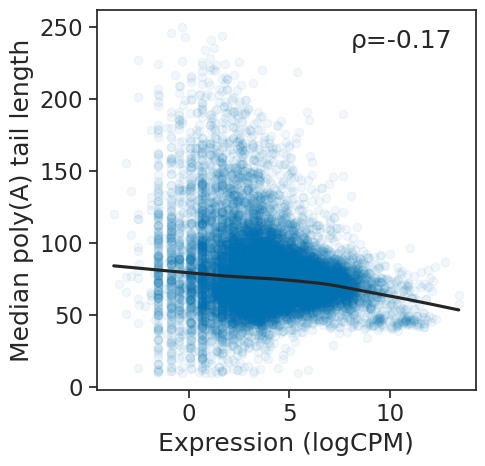

In [97]:
fig, ax = plt.subplots(figsize=(5.2, 5))
plt.tight_layout()
merge_holo_df=pd.merge(expression_common_holo, polya_avg_length_holo_common, left_on='transcript_name', right_on='contig')
sns.regplot(
    x=np.log2(merge_holo_df.cpm_holo),
    y=merge_holo_df.polya_length,
    scatter_kws={'alpha': 0.05, 'rasterized': True},
    line_kws={'color': '#252525'},
    lowess=True, ax=ax
)

ax.set_xlabel('Expression (logCPM)')
ax.set_ylabel('Median poly(A) tail length')

rho, p = stats.spearmanr(merge_holo_df.cpm_holo, merge_holo_df.polya_length)

ax.annotate(xy=(0.67, 0.9), text=f'ρ={rho:.2f}', xycoords='axes fraction') #xy=(0.67, 0.9)
#ax.axhline(y=rho, color='red', linestyle='--', label=f'ρ={rho:.2f}')

plt.tight_layout()
#plt.savefig('median_polya_length_vs_median_expression_holo_6samples_express.svg')
plt.show()

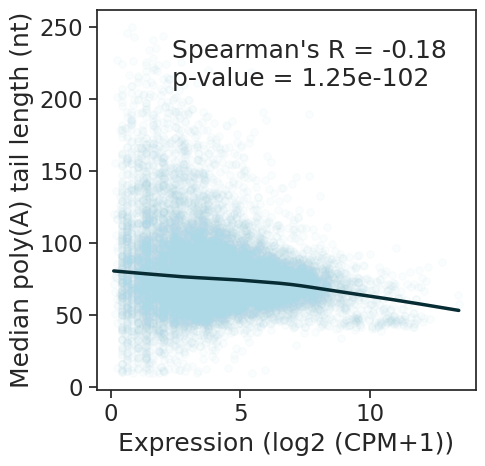

In [98]:
fig, ax = plt.subplots(figsize=(5.2, 5))
plt.tight_layout()

merge_holo_df = pd.merge(
    expression_common_holo,
    polya_avg_length_holo_common,
    left_on='transcript_name',
    right_on='contig'
)
plot_df = merge_holo_df[merge_holo_df["cpm_holo"] > 0].copy()
sns.regplot(
    x=np.log2(plot_df["cpm_holo"]+1),
    y=plot_df["polya_length"],
    scatter_kws={'alpha': 0.05, 'rasterized': True,'color':'lightblue','s':28},
    line_kws={'color': "#072C34",'linewidth': 2.5},
    lowess=True, ax=ax
)

ax.set_xlabel('Expression (log2 (CPM+1))')
ax.set_ylabel('Median poly(A) tail length (nt)')

rho, p = stats.spearmanr(plot_df["cpm_holo"], plot_df["polya_length"])

ax.annotate(    f"Spearman's R = {rho:.2f}\np-value = {p:.2e}",
    xy=(0.2, 0.80),
    #xy=(0.67, 0.9), text=f'ρ={rho:.2f}', 
    xycoords='axes fraction') #xy=(0.67, 0.9)
#ax.axhline(y=rho, color='red', linestyle='--', label=f'ρ={rho:.2f}')

plt.tight_layout()
plt.savefig('median_polya_length_vs_median_expression_holo_isoquant.png',dpi=300, transparent=True)
plt.show()

In [99]:
print(rho, p)

-0.17613658060294668 1.2454941416636999e-102


In [100]:
plot_df.shape

(14684, 17)

In [101]:
boot_res = []

s = plot_df[['cpm_holo','polya_length']] #pd.concat([expression_common_holo['cpm_holo'], polya_avg_length_holo_common['polya_length']],axis=1)
n = len(s)

for _ in range(10_000):
    samp = s.sample(n=n, replace=True)
    boot_res.append(stats.spearmanr(samp['cpm_holo'], samp['polya_length'])[0])

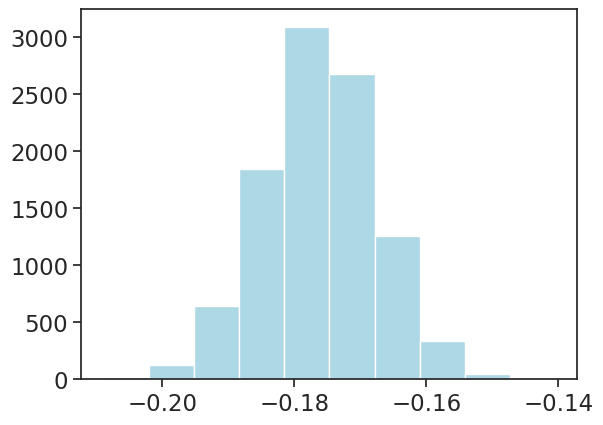

In [102]:
plt.hist(boot_res,color='lightblue')
plt.savefig('spearman_bootstrap_distribution_holo_isoquant.png',dpi=300, transparent=True)
plt.show()

In [103]:
np.percentile(boot_res, (2.5, 97.5))

array([-0.19291755, -0.15952793])

In [104]:
expression_common_apo['transcript_name'].unique

<bound method Series.unique of 0                                   AIPGENE10002
1                                   AIPGENE10004
2                                   AIPGENE10007
3                                    AIPGENE1001
4                                   AIPGENE10010
                          ...                   
15274     transcript998.scaffold54size781874.nic
15275     transcript998.scaffold71size717949.nic
15276    transcript998.scaffold92size630311.nnic
15277    transcript999.scaffold71size717949.nnic
15278    transcript999.scaffold72size711675.nnic
Name: transcript_name, Length: 15279, dtype: object>

In [105]:
expression_common_holo_6_samples

,transcript_name,A1,A2,A3,H1,H2,H3,cpm_A1,cpm_A2,cpm_A3,cpm_H1,cpm_H2,cpm_H3,cpm_holo,cpm_apo
0,AIPGENE10002,110.0,57.00,128.0,23.0,159.00,123.00,92.923934,53.882473,41.498737,35.323881,55.039520,64.734873,93.809497,114.043010
1,AIPGENE10003,1.0,0.00,0.0,1.0,5.00,0.00,0.844763,0.000000,0.000000,1.535821,1.730803,0.000000,1.730803,1.689526
2,AIPGENE10004,13.0,14.00,36.0,11.0,31.00,23.00,10.981920,13.234292,11.671520,16.894030,10.730976,12.104895,12.286567,15.628116
3,AIPGENE10007,46.0,45.00,137.0,36.0,136.00,98.00,38.859100,42.538794,44.416617,55.289552,47.077829,51.577378,11.077136,9.077849
4,AIPGENE1001,7.0,10.00,24.0,3.0,19.00,10.00,5.913341,9.453065,7.781013,4.607463,6.577050,5.262998,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15111,transcript998.scaffold54size781874.nic,39.0,137.00,82.0,20.5,144.50,78.50,32.945759,129.506996,26.585128,31.484328,50.020193,41.314533,5.173527,4.887235
15112,transcript998.scaffold71size717949.nic,4.5,6.50,22.0,5.0,16.50,9.50,3.801434,6.144493,7.132595,7.679104,5.711648,4.999848,3.071642,0.486313
15113,transcript998.scaffold92size630311.nnic,10.5,8.00,38.0,5.5,37.00,18.50,8.870012,7.562452,12.319938,8.447015,12.807939,9.736546,7.961692,1.458940
15114,transcript999.scaffold71size717949.nnic,21.0,8.33,56.0,13.0,47.67,48.67,17.740024,7.874403,18.155697,19.965672,16.501471,25.615010,1112.071433,1203.139160


# check the result from the nanopolish polya-diff

In [97]:
for fn in [x for x in glob('../../../raw_data/A*/nanopolish/polya_results_new_isoquant_transcriptome.tsv') if 'ERCC' not in x]:
    sample = fn.split('/')[4]
    p = pd.read_table(
        fn, sep='\t',
        index_col='readname'
    )
    p = p[p['qc_tag'] == 'PASS']
    fn_new=fn.replace('polya_results_new_isoquant_transcriptome.tsv', 'polya_results_new_isoquant_transcriptome_pass_only.tsv')
    p.to_csv(fn_new, sep='\t')

In [98]:
for fn in [x for x in glob('../../../raw_data/H*/nanopolish/polya_results_new_isoquant_transcriptome.tsv') if 'ERCC' not in x]:
    sample = fn.split('/')[4]
    p = pd.read_table(
        fn, sep='\t',
        index_col='readname'
    )
    p = p[p['qc_tag'] == 'PASS']
    fn_new=fn.replace('polya_results_new_isoquant_transcriptome.tsv', 'polya_results_new_isoquant_transcriptome_pass_only.tsv')
    p.to_csv(fn_new, sep='\t')

In [51]:
diff=pd.read_table('/ibex/scratch/projects/c2101/aip_epitrans_analysis/pipeline-polya-diff/report/polya_diff_per_transcript.tsv',sep='\t')

In [107]:
diff

,Unnamed: 0,count,count.1,median,median.1,median.2,u,p-value,FDR
0,group,control,treatment,control,diff,treatment,NaN,NaN,NaN
1,contig,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AIPGENE20026,89813.0,47641.0,59.0,-5.020000000000003,53.98,2.373010e+09,3.702787e-244,6.596886e-240
3,AIPGENE27854,6944.0,2508.0,56.82,39.23500000000001,96.055,5.123252e+06,1.105287e-205,9.845898e-202
4,AIPGENE20952,37988.0,43443.0,49.23,-4.589999999999996,44.64,8.995781e+08,1.449787e-109,8.609799e-106
...,...,...,...,...,...,...,...,...,...
17813,transcript659.scaffold66size737514.nnic,16.0,12.0,94.83000000000001,1.8199999999999932,96.65,9.700000e+01,9.814812e-01,1.000000e+00
17814,AIPGENE17693,14.0,11.0,74.25,43.19,117.44,7.700000e+01,1.000000e+00,1.000000e+00
17815,AIPGENE7538,10.0,12.0,80.77,-3.885000000000005,76.88499999999999,6.000000e+01,1.000000e+00,1.000000e+00
17816,AIPGENE16069,49.0,47.0,92.55,-5.640000000000001,86.91,1.153000e+03,9.941522e-01,1.000000e+00


In [52]:
diff=diff.iloc[2:]

In [53]:
diff

,Unnamed: 0,count,count.1,median,median.1,median.2,u,p-value,FDR
2,AIPGENE20026,89813.0,47641.0,59.0,-5.020000000000003,53.98,2.373010e+09,3.702787e-244,6.596886e-240
3,AIPGENE27854,6944.0,2508.0,56.82,39.23500000000001,96.055,5.123252e+06,1.105287e-205,9.845898e-202
4,AIPGENE20952,37988.0,43443.0,49.23,-4.589999999999996,44.64,8.995781e+08,1.449787e-109,8.609799e-106
5,AIPGENE820,16291.0,15746.0,54.54,-12.699999999999996,41.84,1.458944e+08,9.178303e-101,4.088016e-97
6,AIPGENE7996,12751.0,13527.0,58.39,-14.530000000000001,43.86,9.836143e+07,1.438423e-86,5.125390e-83
...,...,...,...,...,...,...,...,...,...
17813,transcript659.scaffold66size737514.nnic,16.0,12.0,94.83000000000001,1.8199999999999932,96.65,9.700000e+01,9.814812e-01,1.000000e+00
17814,AIPGENE17693,14.0,11.0,74.25,43.19,117.44,7.700000e+01,1.000000e+00,1.000000e+00
17815,AIPGENE7538,10.0,12.0,80.77,-3.885000000000005,76.88499999999999,6.000000e+01,1.000000e+00,1.000000e+00
17816,AIPGENE16069,49.0,47.0,92.55,-5.640000000000001,86.91,1.153000e+03,9.941522e-01,1.000000e+00


In [54]:
diff=diff.rename({'Unnamed: 0':'gene','count':'apo_count','count.1':'holo_count',
                    'median':'median_apo','median.1':'median_diff','median.2':'median_holo'},axis=1)
diff

,gene,apo_count,holo_count,median_apo,median_diff,median_holo,u,p-value,FDR
2,AIPGENE20026,89813.0,47641.0,59.0,-5.020000000000003,53.98,2.373010e+09,3.702787e-244,6.596886e-240
3,AIPGENE27854,6944.0,2508.0,56.82,39.23500000000001,96.055,5.123252e+06,1.105287e-205,9.845898e-202
4,AIPGENE20952,37988.0,43443.0,49.23,-4.589999999999996,44.64,8.995781e+08,1.449787e-109,8.609799e-106
5,AIPGENE820,16291.0,15746.0,54.54,-12.699999999999996,41.84,1.458944e+08,9.178303e-101,4.088016e-97
6,AIPGENE7996,12751.0,13527.0,58.39,-14.530000000000001,43.86,9.836143e+07,1.438423e-86,5.125390e-83
...,...,...,...,...,...,...,...,...,...
17813,transcript659.scaffold66size737514.nnic,16.0,12.0,94.83000000000001,1.8199999999999932,96.65,9.700000e+01,9.814812e-01,1.000000e+00
17814,AIPGENE17693,14.0,11.0,74.25,43.19,117.44,7.700000e+01,1.000000e+00,1.000000e+00
17815,AIPGENE7538,10.0,12.0,80.77,-3.885000000000005,76.88499999999999,6.000000e+01,1.000000e+00,1.000000e+00
17816,AIPGENE16069,49.0,47.0,92.55,-5.640000000000001,86.91,1.153000e+03,9.941522e-01,1.000000e+00


In [55]:
diff=diff.reset_index(drop=True)

In [56]:
diff

,gene,apo_count,holo_count,median_apo,median_diff,median_holo,u,p-value,FDR
0,AIPGENE20026,89813.0,47641.0,59.0,-5.020000000000003,53.98,2.373010e+09,3.702787e-244,6.596886e-240
1,AIPGENE27854,6944.0,2508.0,56.82,39.23500000000001,96.055,5.123252e+06,1.105287e-205,9.845898e-202
2,AIPGENE20952,37988.0,43443.0,49.23,-4.589999999999996,44.64,8.995781e+08,1.449787e-109,8.609799e-106
3,AIPGENE820,16291.0,15746.0,54.54,-12.699999999999996,41.84,1.458944e+08,9.178303e-101,4.088016e-97
4,AIPGENE7996,12751.0,13527.0,58.39,-14.530000000000001,43.86,9.836143e+07,1.438423e-86,5.125390e-83
...,...,...,...,...,...,...,...,...,...
17811,transcript659.scaffold66size737514.nnic,16.0,12.0,94.83000000000001,1.8199999999999932,96.65,9.700000e+01,9.814812e-01,1.000000e+00
17812,AIPGENE17693,14.0,11.0,74.25,43.19,117.44,7.700000e+01,1.000000e+00,1.000000e+00
17813,AIPGENE7538,10.0,12.0,80.77,-3.885000000000005,76.88499999999999,6.000000e+01,1.000000e+00,1.000000e+00
17814,AIPGENE16069,49.0,47.0,92.55,-5.640000000000001,86.91,1.153000e+03,9.941522e-01,1.000000e+00


In [57]:
diff[diff['p-value']<0.05]

,gene,apo_count,holo_count,median_apo,median_diff,median_holo,u,p-value,FDR
0,AIPGENE20026,89813.0,47641.0,59.0,-5.020000000000003,53.98,2.373010e+09,3.702787e-244,6.596886e-240
1,AIPGENE27854,6944.0,2508.0,56.82,39.23500000000001,96.055,5.123252e+06,1.105287e-205,9.845898e-202
2,AIPGENE20952,37988.0,43443.0,49.23,-4.589999999999996,44.64,8.995781e+08,1.449787e-109,8.609799e-106
3,AIPGENE820,16291.0,15746.0,54.54,-12.699999999999996,41.84,1.458944e+08,9.178303e-101,4.088016e-97
4,AIPGENE7996,12751.0,13527.0,58.39,-14.530000000000001,43.86,9.836143e+07,1.438423e-86,5.125390e-83
...,...,...,...,...,...,...,...,...,...
2873,transcript684.scaffold62size746220.nic,118.0,311.0,94.15,-16.440000000000012,77.71,2.059850e+04,4.985422e-02,3.088867e-01
2874,AIPGENE6258,44.0,55.0,91.21000000000001,-29.150000000000006,62.06,1.489000e+03,4.986294e-02,3.088867e-01
2875,AIPGENE26150,31.0,25.0,79.27,-35.23,44.04,5.070000e+02,4.984126e-02,3.088867e-01
2876,transcript1418.scaffold134size502784.nnic,61.0,17.0,81.31,-22.260000000000005,59.05,6.810000e+02,4.991847e-02,3.091232e-01


In [58]:
diff=diff[diff['FDR']<0.05]
diff

,gene,apo_count,holo_count,median_apo,median_diff,median_holo,u,p-value,FDR
0,AIPGENE20026,89813.0,47641.0,59.0,-5.020000000000003,53.98,2.373010e+09,3.702787e-244,6.596886e-240
1,AIPGENE27854,6944.0,2508.0,56.82,39.23500000000001,96.055,5.123252e+06,1.105287e-205,9.845898e-202
2,AIPGENE20952,37988.0,43443.0,49.23,-4.589999999999996,44.64,8.995781e+08,1.449787e-109,8.609799e-106
3,AIPGENE820,16291.0,15746.0,54.54,-12.699999999999996,41.84,1.458944e+08,9.178303e-101,4.088016e-97
4,AIPGENE7996,12751.0,13527.0,58.39,-14.530000000000001,43.86,9.836143e+07,1.438423e-86,5.125390e-83
...,...,...,...,...,...,...,...,...,...
946,AIPGENE10977,78.0,74.0,57.620000000000005,-17.790000000000006,39.83,3.702500e+03,2.630042e-03,4.946544e-02
947,AIPGENE10874,282.0,270.0,84.905,-13.055000000000007,71.85,4.370450e+04,2.632086e-03,4.946544e-02
948,AIPGENE24018,1199.0,598.0,67.68,-7.845000000000006,59.835,3.896715e+05,2.636055e-03,4.948783e-02
949,AIPGENE13962,24.0,73.0,107.905,-42.665000000000006,65.24,1.236000e+03,2.651887e-03,4.973264e-02


In [115]:
diff.to_csv('../../polya/diff_polya_genes_between_conditions_6samples_isoquant.csv')

In [60]:
polya_avg_length_holo_common

,contig,polya_length
2,AIPGENE10002,72.78
3,AIPGENE10003,70.38
4,AIPGENE10004,55.63
6,AIPGENE10007,80.56
8,AIPGENE1001,85.39
...,...,...
27856,transcript998.scaffold54size781874.nic,84.82
27857,transcript998.scaffold71size717949.nic,197.54
27858,transcript998.scaffold92size630311.nnic,59.61
27859,transcript999.scaffold71size717949.nnic,71.79


(736, 17)


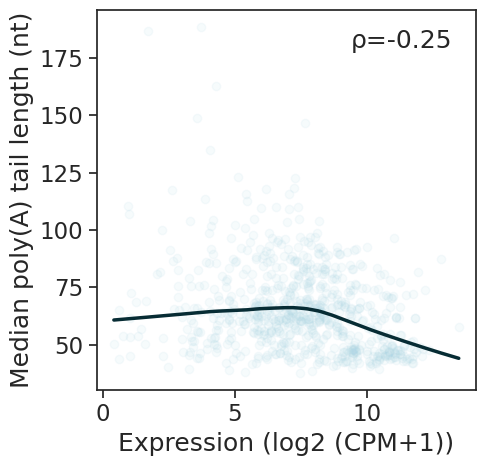

In [61]:
## inverstigate the polyA tail length with the gene expression level
fig, ax = plt.subplots(figsize=(5.2, 5))
plt.tight_layout()

merge_holo_df = pd.merge(
    expression_common_holo,
    polya_avg_length_holo_common,
    left_on='transcript_name',
    right_on='contig'
)
plot_df = merge_holo_df[merge_holo_df["cpm_holo"] > 0].copy()
plot_df=plot_df[plot_df['transcript_name'].isin(diff['gene'])]
print(plot_df.shape)

sns.regplot(
    x=np.log2(plot_df["cpm_holo"]+1),
    y=plot_df["polya_length"],
    scatter_kws={'alpha': 0.1, 'rasterized': True,'color':'lightblue'},
    line_kws={'color': "#072C34",'linewidth': 2.5},
    lowess=True, ax=ax
)

ax.set_xlabel('Expression (log2 (CPM+1))')
ax.set_ylabel('Median poly(A) tail length (nt)')

rho, p = stats.spearmanr(plot_df["cpm_holo"], plot_df["polya_length"])

ax.annotate(xy=(0.67, 0.9), text=f'ρ={rho:.2f}', xycoords='axes fraction') #xy=(0.67, 0.9)
#ax.axhline(y=rho, color='red', linestyle='--', label=f'ρ={rho:.2f}')

plt.tight_layout()
plt.savefig('median_polya_length_vs_median_expression_holo_only_on_diff_polyA_genes'+str(len(plot_df))+'_isoquant.png',dpi=300, transparent=True)
plt.show()

In [62]:
print(rho, p)

-0.2509930942260271 4.895067926327169e-12


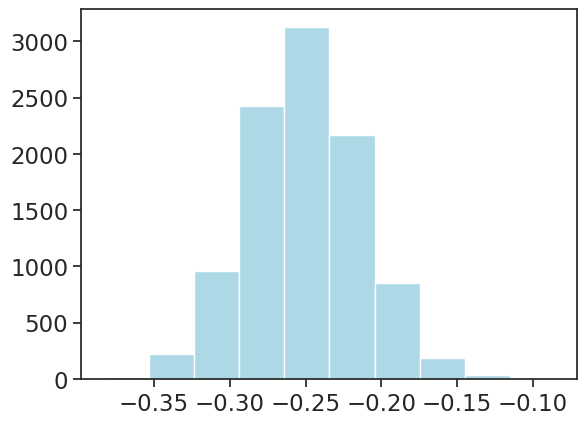

In [63]:
boot_res = []

s = plot_df[['cpm_holo','polya_length']] #pd.concat([expression_common_holo['cpm_holo'], polya_avg_length_holo_common['polya_length']],axis=1)
n = len(s)

for _ in range(10_000):
    samp = s.sample(n=n, replace=True)
    boot_res.append(stats.spearmanr(samp['cpm_holo'], samp['polya_length'])[0])
plt.hist(boot_res,color='lightblue')
plt.savefig('spearman_bootstrap_distribution_holo_only_on_diff_polyA_genes'+str(len(plot_df))+'_isoquant.png',dpi=300, transparent=True)
plt.show()

In [64]:
np.percentile(boot_res, (2.5, 97.5))

array([-0.32251458, -0.17627732])

(731, 17)


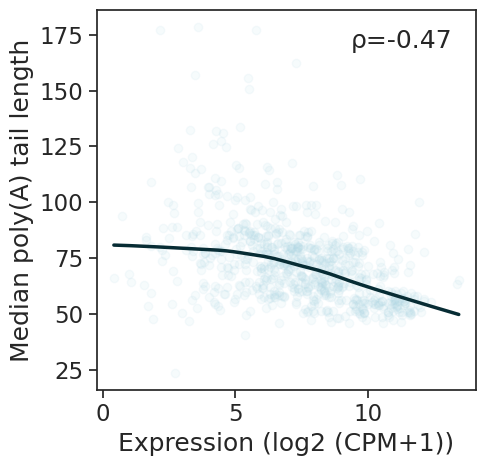

In [66]:
## inverstigate the polyA tail length with the gene expression level
fig, ax = plt.subplots(figsize=(5.2, 5))
plt.tight_layout()

merge_apo_df = pd.merge(
    expression_common_apo,
    polya_avg_length_apo_common,
    left_on='transcript_name',
    right_on='contig'
)
plot_df = merge_apo_df[merge_apo_df["cpm_apo"] > 0].copy()
plot_df=plot_df[plot_df['transcript_name'].isin(diff['gene'])]
print(plot_df.shape)

sns.regplot(
    x=np.log2(plot_df["cpm_apo"]+1),
    y=plot_df["polya_length"],
    scatter_kws={'alpha': 0.1, 'rasterized': True,'color':'lightblue'},
    line_kws={'color': "#072C34",'linewidth': 2.5},
    lowess=True, ax=ax
)

ax.set_xlabel('Expression (log2 (CPM+1))')
ax.set_ylabel('Median poly(A) tail length')

rho, p = stats.spearmanr(plot_df["cpm_apo"], plot_df["polya_length"])

ax.annotate(xy=(0.67, 0.9), text=f'ρ={rho:.2f}', xycoords='axes fraction') #xy=(0.67, 0.9)
#ax.axhline(y=rho, color='red', linestyle='--', label=f'ρ={rho:.2f}')

plt.tight_layout()
plt.savefig('median_polya_length_vs_median_expression_apo_only_on_diff_polyA_genes'+str(len(plot_df))+'_isoquant.png',dpi=300, transparent=True)
plt.show()

In [67]:
print(rho, p)

-0.470641066664908 1.4415409708023072e-41


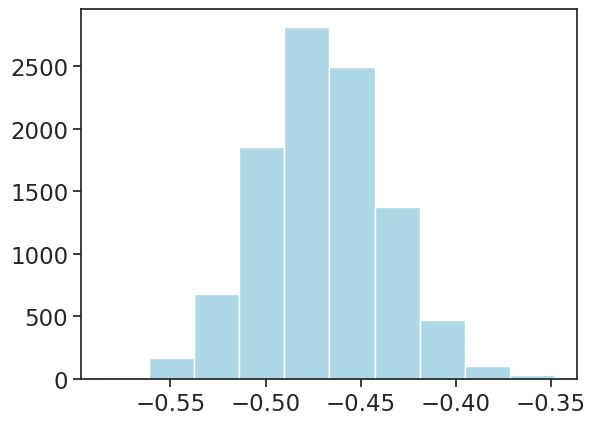

In [68]:
boot_res = []

s = plot_df[['cpm_apo','polya_length']] #pd.concat([expression_common_apo['cpm_apo'], polya_avg_length_apo_common['polya_length']],axis=1)
n = len(s)

for _ in range(10_000):
    samp = s.sample(n=n, replace=True)
    boot_res.append(stats.spearmanr(samp['cpm_apo'], samp['polya_length'])[0])
plt.hist(boot_res,color='lightblue')
plt.savefig('spearman_bootstrap_distribution_apo_only_on_diff_polyA_genes'+str(len(plot_df))+'_isoquant.png',dpi=300, transparent=True)
plt.show()

In [69]:
np.percentile(boot_res, (2.5, 97.5))

array([-0.53329541, -0.40338086])

In [70]:
isoquant=pd.read_csv('/ibex/scratch/projects/c2101/aip_epitrans_analysis/isoquant/outputs/final_all_ref/OUT/diffexpr-results-isoquant-genes-6samples_update_from_transcript_model_transcript_level_raw.csv',header=0,index_col=0) # i previous used diffexpr-results-isoquant-genes-6samples.csv, which is the result based onthe transcript level
isoquant

,transcript_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,A1,A2,A3,H1,H2,H3,Gene,Preferred_name,Description,deg_result
1,AIPGENE10002,87.425732,0.049266,0.550096,0.089559,0.928637,0.998185,145.108731,78.234321,62.522324,57.387058,84.779131,96.522824,AIPGENE10002_gene,ETV6,mesenchymal cell apoptotic process,down
2,AIPGENE10003,1.080045,2.725782,3.497112,0.779438,0.435722,NaN,1.319170,0.000000,0.000000,2.495089,2.666010,0.000000,AIPGENE10003_gene,NaN,NaN,up
3,AIPGENE10004,19.328883,0.039671,0.755066,0.052540,0.958098,0.998185,17.149214,19.215447,17.584404,27.445984,16.529265,18.048983,AIPGENE10004_gene,NaN,NaN,down
4,AIPGENE10007,71.434544,0.350419,0.464626,0.754195,0.450732,0.930628,60.681833,61.763938,66.918425,89.823221,72.515483,76.904364,AIPGENE10007_gene,PEX3,protein import into peroxisome membrane,down
5,AIPGENE1001,10.024323,-0.659594,0.963543,-0.684551,0.493628,0.946126,9.234192,13.725320,11.722936,7.485268,10.130840,7.847384,AIPGENE1001_gene,PPIL3,peptidyl-prolyl cis-trans isomerase activity,down
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15402,transcript998.scaffold54size781874.nic,77.905061,-1.552905,0.452797,-3.429584,0.000605,0.017898,51.447641,188.036878,40.053364,49.901789,76.781100,61.209596,AIPGENE22675_gene,NaN,NaN,down
15403,transcript998.scaffold71size717949.nic,8.851994,0.163912,1.083593,0.151267,0.879765,NaN,5.276681,8.235192,10.746024,12.475447,8.531233,7.847384,AIPGENE10547_gene,NaN,C2 domain-containing protein,down
15404,transcript998.scaffold92size630311.nnic,15.259596,0.589883,0.874906,0.674224,0.500169,0.946347,13.191703,10.980256,18.561315,14.970537,19.728477,14.125291,AIPGENE12792_gene,ADAP2,ArfGAP with dual PH,down
15405,transcript999.scaffold71size717949.nnic,27.086399,1.542331,0.762834,2.021843,0.043193,0.342089,27.702576,10.980256,27.353517,32.436163,25.593700,38.452182,AIPGENE10555_gene,NaN,NaN,up


In [71]:
isoquant=isoquant[isoquant['padj']<0.05]
isoquant

,transcript_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,A1,A2,A3,H1,H2,H3,Gene,Preferred_name,Description,deg_result
71,AIPGENE10332,159.077720,-1.295403,0.376754,-3.438329,0.000585,0.017567,124.002007,328.035137,105.506422,117.269205,154.095402,125.558146,AIPGENE10332_gene,SMPD1,acid sphingomyelin phosphodiesterase activity,down
89,AIPGENE10421,81.287745,-1.759570,0.558683,-3.149499,0.001636,0.038426,87.065239,197.644601,31.261162,42.416521,61.851441,67.487503,AIPGENE10421_gene,NaN,metalloendopeptidase activity,down
95,AIPGENE10493,2465.136839,-1.045968,0.315274,-3.317653,0.000908,0.024487,3111.922702,3628.974486,2770.032035,2031.002831,1781.428154,1467.460827,AIPGENE10493_gene,TUBB4B,Tubulin beta-4B,down
116,AIPGENE10554,121.571928,1.503303,0.459542,3.271310,0.001071,0.027587,108.171963,57.646342,70.337615,179.646442,138.632541,174.996665,AIPGENE10554_gene,NaN,NaN,up
117,AIPGENE10555,143.832242,1.714103,0.441297,3.884237,0.000103,0.004431,127.959518,57.646342,106.483333,207.092426,150.362987,213.448847,AIPGENE10555_gene,NaN,NaN,up
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15372,transcript991.scaffold245size345188.nnic,19.287521,6.977282,2.139154,3.261701,0.001107,0.028407,10.553362,0.000000,12.211391,22.455805,35.191337,35.313228,AIPGENE4241_gene,NaN,NaN,up
15375,transcript991.scaffold95size625746.nic,3403.425948,1.434665,0.330327,4.343165,0.000014,0.000808,1539.471722,1940.760183,1210.393120,4314.009699,6114.228268,5301.692697,AIPGENE764_gene,NaN,NaN,up
15380,transcript993.scaffold2size2342127.nnic,98.546549,2.505556,0.639457,3.918256,0.000089,0.003898,73.873536,23.333043,105.017966,57.387058,151.962593,179.705096,AIPGENE3067_gene,NaN,MAC/Perforin domain,up
15383,transcript993.scaffold76size705516.nnic,54.922999,-1.932972,0.491232,-3.934947,0.000083,0.003696,62.001003,119.410280,56.172401,27.445984,36.257742,28.250583,AIPGENE26095_gene,NaN,Clavaminate synthase-like protein At3g21360-like,down


In [72]:
diff.head()

,gene,apo_count,holo_count,median_apo,median_diff,median_holo,u,p-value,FDR
0,AIPGENE20026,89813.0,47641.0,59.0,-5.020000000000003,53.98,2.373010e+09,3.702787e-244,6.596886e-240
1,AIPGENE27854,6944.0,2508.0,56.82,39.23500000000001,96.055,5.123252e+06,1.105287e-205,9.845898e-202
2,AIPGENE20952,37988.0,43443.0,49.23,-4.589999999999996,44.64,8.995781e+08,1.449787e-109,8.609799e-106
3,AIPGENE820,16291.0,15746.0,54.54,-12.699999999999996,41.84,1.458944e+08,9.178303e-101,4.088016e-97
4,AIPGENE7996,12751.0,13527.0,58.39,-14.530000000000001,43.86,9.836143e+07,1.438423e-86,5.125390e-83


In [73]:
merged_diff_polya_deg_isoquant = pd.merge(diff, isoquant, left_on=['gene'],right_on=['transcript_id'], how='inner')
merged_diff_polya_deg_isoquant

,gene,apo_count,holo_count,median_apo,median_diff,median_holo,u,p-value,FDR,transcript_id,...,A1,A2,A3,H1,H2,H3,Gene,Preferred_name,Description,deg_result
0,transcript2289.scaffold297size308578.nnic,4118.0,5555.0,60.695,-9.655000000000001,51.04,13348416.0,5.822672e-45,6.102161e-42,transcript2289.scaffold297size308578.nnic,...,76.511877,27.450639,72.779893,261.984395,172.757474,156.162944,AIPGENE6868_gene,NaN,neurotransmitter:sodium symporter activity,up
1,AIPGENE19986,685.0,541.0,63.76,46.57,110.33,105742.0,3.336982e-38,2.123274e-35,AIPGENE19986,...,205.790564,91.959641,424.467966,269.469663,232.476107,268.380536,AIPGENE19986_gene,PHGDH,Belongs to the D-isomer specific 2-hydroxyacid...,up
2,transcript1615.scaffold414size184771.nnic,3667.0,2266.0,70.48,-16.820000000000007,53.66,4871692.0,4.825115e-29,1.790922e-26,transcript1615.scaffold414size184771.nnic,...,1287.510198,1829.585094,1172.782034,726.071037,837.127268,1043.702085,AIPGENE5624_gene,NaN,NaN,down
3,transcript1620.scaffold414size184771.nnic,2019.0,1781.0,77.54,-18.150000000000006,59.39,2167713.0,6.135711e-28,1.987524e-25,transcript1620.scaffold414size184771.nnic,...,873.290728,0.000000,682.861009,371.768332,448.956153,604.248576,AIPGENE5625_gene,NaN,NaN,up
4,AIPGENE21459,11223.0,5702.0,58.77,6.475000000000001,65.245,28779378.0,9.233506e-27,2.570377e-24,AIPGENE21459,...,4942.931057,6544.232355,4759.511928,3685.247152,2675.608045,2774.050279,AIPGENE21459_gene,CAT,Occurs in almost all aerobically respiring org...,down
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,transcript1865.scaffold369size229073.nnic,551.0,167.0,61.93,-10.189999999999998,51.74,53291.5,1.925385e-03,3.889190e-02,transcript1865.scaffold369size229073.nnic,...,155.662094,339.015393,110.390979,114.774116,164.759443,109.863377,AIPGENE8046_gene,NaN,NaN,down
70,transcript1964.scaffold207size385297.nnic,253.0,82.0,83.81,-31.28,52.53,12723.5,2.046898e-03,4.092877e-02,transcript1964.scaffold207size385297.nnic,...,94.980260,135.880663,70.337615,22.455805,29.859317,30.604798,AIPGENE19802_gene,NaN,electron carrier activity. It is involved in t...,down
71,AIPGENE21626,1083.0,502.0,66.61,10.03500000000001,76.64500000000001,245865.0,2.188404e-03,4.332067e-02,AIPGENE21626,...,547.455668,741.167255,568.562385,431.650479,324.186866,269.950013,AIPGENE21626_gene,COPZ1,intra-Golgi vesicle-mediated transport,down
72,transcript240.scaffold11size1250908.nnic,341.0,1275.0,95.12,-13.16000000000001,81.96,240723.5,2.298028e-03,4.499085e-02,transcript240.scaffold11size1250908.nnic,...,72.554366,183.919282,48.845566,334.341989,508.674786,518.712089,AIPGENE17421_gene,amt-1,ammonium transmembrane transporter activity,up


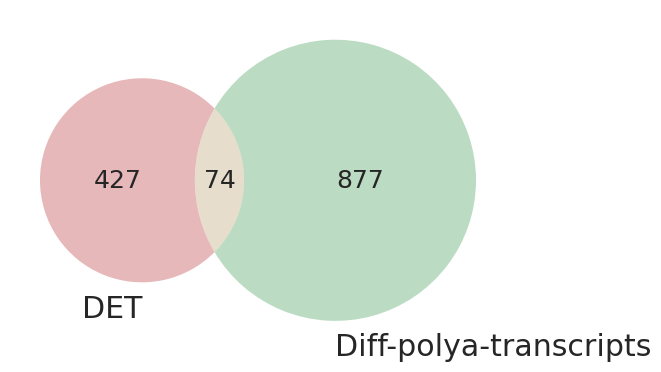

In [74]:
from matplotlib_venn import venn2
set1 = set(isoquant['transcript_id'])
set2 = set(diff['gene'])

venn2([set1, set2], ('DET', 'Diff-polya-transcripts'))
plt.savefig('venn_diff_polya_deg_isoquant_6samples_deg_based_on_transcript_models_isoquant.png',dpi=300, transparent=True)
plt.show()

In [75]:
all_tested_polya=pd.read_table('/ibex/scratch/projects/c2101/aip_epitrans_analysis/pipeline-polya-diff/report/polya_diff_per_transcript.tsv',sep='\t')
all_tested_polya=all_tested_polya.iloc[2:]
all_tested_polya.head()

all_tested_det=pd.read_csv('/ibex/scratch/projects/c2101/aip_epitrans_analysis/isoquant/outputs/final_all_ref/OUT/diffexpr-results-isoquant-genes-6samples_update_from_transcript_model_transcript_level_raw.csv',header=0,index_col=0) # i previous used diffexpr-results-isoquant-genes-6samples.csv, which is the result based onthe transcript level
all_tested_det.head()

,transcript_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,A1,A2,A3,H1,H2,H3,Gene,Preferred_name,Description,deg_result
1,AIPGENE10002,87.425732,0.049266,0.550096,0.089559,0.928637,0.998185,145.108731,78.234321,62.522324,57.387058,84.779131,96.522824,AIPGENE10002_gene,ETV6,mesenchymal cell apoptotic process,down
2,AIPGENE10003,1.080045,2.725782,3.497112,0.779438,0.435722,NaN,1.319170,0.000000,0.000000,2.495089,2.666010,0.000000,AIPGENE10003_gene,NaN,NaN,up
3,AIPGENE10004,19.328883,0.039671,0.755066,0.052540,0.958098,0.998185,17.149214,19.215447,17.584404,27.445984,16.529265,18.048983,AIPGENE10004_gene,NaN,NaN,down
4,AIPGENE10007,71.434544,0.350419,0.464626,0.754195,0.450732,0.930628,60.681833,61.763938,66.918425,89.823221,72.515483,76.904364,AIPGENE10007_gene,PEX3,protein import into peroxisome membrane,down
5,AIPGENE1001,10.024323,-0.659594,0.963543,-0.684551,0.493628,0.946126,9.234192,13.725320,11.722936,7.485268,10.130840,7.847384,AIPGENE1001_gene,PPIL3,peptidyl-prolyl cis-trans isomerase activity,down


In [76]:
all_tested_polya.head()

,Unnamed: 0,count,count.1,median,median.1,median.2,u,p-value,FDR
2,AIPGENE20026,89813.0,47641.0,59.0,-5.020000000000003,53.98,2.373010e+09,3.702787e-244,6.596886e-240
3,AIPGENE27854,6944.0,2508.0,56.82,39.23500000000001,96.055,5.123252e+06,1.105287e-205,9.845898e-202
4,AIPGENE20952,37988.0,43443.0,49.23,-4.589999999999996,44.64,8.995781e+08,1.449787e-109,8.609799e-106
5,AIPGENE820,16291.0,15746.0,54.54,-12.699999999999996,41.84,1.458944e+08,9.178303e-101,4.088016e-97
6,AIPGENE7996,12751.0,13527.0,58.39,-14.530000000000001,43.86,9.836143e+07,1.438423e-86,5.125390e-83


In [77]:
np.intersect1d(all_tested_det['transcript_id'], all_tested_polya['Unnamed: 0'])

array(['AIPGENE10002', 'AIPGENE10004', 'AIPGENE10007', ...,
       'transcript998.scaffold92size630311.nnic',
       'transcript999.scaffold71size717949.nnic',
       'transcript999.scaffold72size711675.nnic'], dtype=object)

In [78]:
from scipy.stats import fisher_exact
# Given values
a = 74  # overlap
b = 427  # in set2 but not in set1
c = 877  # in set1 but not in set2
N = len(np.intersect1d(all_tested_det['transcript_id'], all_tested_polya['Unnamed: 0']))  # total number of genes in the universe (background)
print(N)
# Calculate d
d = N - (a + b + c)

# Contingency table
contingency_table = [[a, b], [c, d]]

# Perform Fisher's Exact Test
odds_ratio, p_value = fisher_exact(contingency_table, alternative='greater')

print(f"Odds Ratio: {odds_ratio}")
print(f"P-value: {p_value}")

11848
Odds Ratio: 2.068954467406717
P-value: 1.6443394473733097e-07


In [79]:
merged_diff_polya_deg_isoquant

,gene,apo_count,holo_count,median_apo,median_diff,median_holo,u,p-value,FDR,transcript_id,...,A1,A2,A3,H1,H2,H3,Gene,Preferred_name,Description,deg_result
0,transcript2289.scaffold297size308578.nnic,4118.0,5555.0,60.695,-9.655000000000001,51.04,13348416.0,5.822672e-45,6.102161e-42,transcript2289.scaffold297size308578.nnic,...,76.511877,27.450639,72.779893,261.984395,172.757474,156.162944,AIPGENE6868_gene,NaN,neurotransmitter:sodium symporter activity,up
1,AIPGENE19986,685.0,541.0,63.76,46.57,110.33,105742.0,3.336982e-38,2.123274e-35,AIPGENE19986,...,205.790564,91.959641,424.467966,269.469663,232.476107,268.380536,AIPGENE19986_gene,PHGDH,Belongs to the D-isomer specific 2-hydroxyacid...,up
2,transcript1615.scaffold414size184771.nnic,3667.0,2266.0,70.48,-16.820000000000007,53.66,4871692.0,4.825115e-29,1.790922e-26,transcript1615.scaffold414size184771.nnic,...,1287.510198,1829.585094,1172.782034,726.071037,837.127268,1043.702085,AIPGENE5624_gene,NaN,NaN,down
3,transcript1620.scaffold414size184771.nnic,2019.0,1781.0,77.54,-18.150000000000006,59.39,2167713.0,6.135711e-28,1.987524e-25,transcript1620.scaffold414size184771.nnic,...,873.290728,0.000000,682.861009,371.768332,448.956153,604.248576,AIPGENE5625_gene,NaN,NaN,up
4,AIPGENE21459,11223.0,5702.0,58.77,6.475000000000001,65.245,28779378.0,9.233506e-27,2.570377e-24,AIPGENE21459,...,4942.931057,6544.232355,4759.511928,3685.247152,2675.608045,2774.050279,AIPGENE21459_gene,CAT,Occurs in almost all aerobically respiring org...,down
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,transcript1865.scaffold369size229073.nnic,551.0,167.0,61.93,-10.189999999999998,51.74,53291.5,1.925385e-03,3.889190e-02,transcript1865.scaffold369size229073.nnic,...,155.662094,339.015393,110.390979,114.774116,164.759443,109.863377,AIPGENE8046_gene,NaN,NaN,down
70,transcript1964.scaffold207size385297.nnic,253.0,82.0,83.81,-31.28,52.53,12723.5,2.046898e-03,4.092877e-02,transcript1964.scaffold207size385297.nnic,...,94.980260,135.880663,70.337615,22.455805,29.859317,30.604798,AIPGENE19802_gene,NaN,electron carrier activity. It is involved in t...,down
71,AIPGENE21626,1083.0,502.0,66.61,10.03500000000001,76.64500000000001,245865.0,2.188404e-03,4.332067e-02,AIPGENE21626,...,547.455668,741.167255,568.562385,431.650479,324.186866,269.950013,AIPGENE21626_gene,COPZ1,intra-Golgi vesicle-mediated transport,down
72,transcript240.scaffold11size1250908.nnic,341.0,1275.0,95.12,-13.16000000000001,81.96,240723.5,2.298028e-03,4.499085e-02,transcript240.scaffold11size1250908.nnic,...,72.554366,183.919282,48.845566,334.341989,508.674786,518.712089,AIPGENE17421_gene,amt-1,ammonium transmembrane transporter activity,up


In [181]:
merged_diff_polya_deg_isoquant.to_csv('merged_diff_polya_deg_isoquant_6samples_overlap_genes_transcript.csv')

In [183]:
pwd

'/ibex/project/c2101/aip_epitrans_analysis/analysis/Simpson_Barton_Nanopore_1/notebooks'

In [81]:
merged_diff_polya_deg_isoquant['log2FC_pollya_length']=10*np.log2(merged_diff_polya_deg_isoquant['median_holo'].astype(float)/merged_diff_polya_deg_isoquant['median_apo'].astype(float))

In [82]:
merged_diff_polya_deg_isoquant.columns

Index(['gene', 'apo_count', 'holo_count', 'median_apo', 'median_diff',
       'median_holo', 'u', 'p-value', 'FDR', 'transcript_id', 'baseMean',
       'log2FoldChange', 'lfcSE', 'stat', 'pvalue', 'padj', 'A1', 'A2', 'A3',
       'H1', 'H2', 'H3', 'Gene', 'Preferred_name', 'Description', 'deg_result',
       'log2FC_pollya_length'],
      dtype='object')

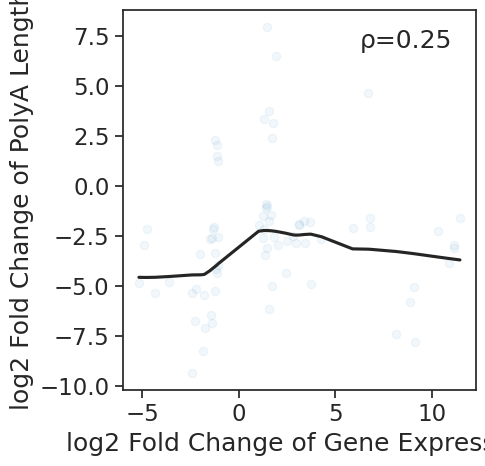

In [87]:
fig, ax = plt.subplots(figsize=(5.2, 5))
plt.tight_layout()

sns.regplot(
    x=merged_diff_polya_deg_isoquant['log2FoldChange'],
    y=merged_diff_polya_deg_isoquant['log2FC_pollya_length'],
    scatter_kws={'alpha': 0.05, 'rasterized': True},
    line_kws={'color': '#252525'},
    lowess=True, ax=ax
)


ax.set_xlabel('log2 Fold Change of Gene Expression')
ax.set_ylabel('log2 Fold Change of PolyA Length')

rho, p = stats.spearmanr(merged_diff_polya_deg_isoquant['log2FoldChange'], merged_diff_polya_deg_isoquant['log2FC_pollya_length'])

ax.annotate(xy=(0.67, 0.9), text=f'ρ={rho:.2f}', xycoords='axes fraction') #xy=(0.67, 0.9)
#ax.axhline(y=rho, color='red', linestyle='--', label=f'ρ={rho:.2f}')

plt.tight_layout()
#plt.savefig('median_polya_length_vs_median_expression_apo_6samples_express.svg')
plt.show()

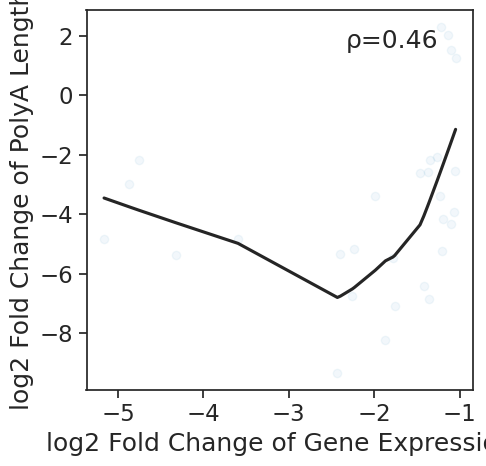

In [90]:
fig, ax = plt.subplots(figsize=(5.2, 5))
plt.tight_layout()

temp=merged_diff_polya_deg_isoquant[merged_diff_polya_deg_isoquant['log2FoldChange']<0]
sns.regplot(
    x=temp['log2FoldChange'],
    y=temp['log2FC_pollya_length'],
    scatter_kws={'alpha': 0.05, 'rasterized': True},
    line_kws={'color': '#252525'},
    lowess=True, ax=ax
)


ax.set_xlabel('log2 Fold Change of Gene Expression')
ax.set_ylabel('log2 Fold Change of PolyA Length')

rho, p = stats.spearmanr(temp['log2FoldChange'], temp['log2FC_pollya_length'])

ax.annotate(xy=(0.67, 0.9), text=f'ρ={rho:.2f}', xycoords='axes fraction') #xy=(0.67, 0.9)
#ax.axhline(y=rho, color='red', linestyle='--', label=f'ρ={rho:.2f}')

plt.tight_layout()
#plt.savefig('median_polya_length_vs_median_expression_apo_6samples_express.svg')
plt.show()

In [91]:
merged_diff_polya_deg_isoquant.shape

(74, 27)

In [139]:
pd.DataFrame(merged_diff_polya_deg_isoquant['gene']).to_csv('diff_polya_genes_isoquant_deg_based_on_transcript_models_6samples_isoquant.txt', sep='\t', index=False)

In [140]:
pwd

'/ibex/project/c2101/aip_epitrans_analysis/analysis/Simpson_Barton_Nanopore_1/notebooks'

In [141]:
merged_diff_polya_deg_isoquant.columns

Index(['gene', 'apo_count', 'holo_count', 'median_apo', 'median_diff',
       'median_holo', 'u', 'p-value', 'FDR', 'transcript_id', 'baseMean',
       'log2FoldChange', 'lfcSE', 'stat', 'pvalue', 'padj', 'A1', 'A2', 'A3',
       'H1', 'H2', 'H3', 'Gene', 'Preferred_name', 'Description', 'deg_result',
       'log2FC_pollya_length'],
      dtype='object')

In [142]:
print(rho,p)

0.45665024630541856 0.012769716684940896


# Subset the genes that have longer polyA length in two conditions and check their relationship with the gene expression (not necessary the DEG)

In [92]:
diff['log2PolyAFC']=np.log2(diff['median_holo'].astype(float)/diff['median_apo'].astype(float))

/tmp/ipykernel_800951/3837228683.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  diff['log2PolyAFC']=np.log2(diff['median_holo'].astype(float)/diff['median_apo'].astype(float))


In [93]:
diff_holo_longer=diff[diff['log2PolyAFC']>0]
diff_apo_longer=diff[diff['log2PolyAFC']<0]

In [94]:
print(diff_holo_longer.shape)
print(diff_apo_longer.shape)

(202, 10)
(749, 10)


In [95]:
merge_holo_longer_df=pd.merge(expression, diff_holo_longer, left_on='transcript_name', right_on='gene')
merge_holo_longer_df

,transcript_name,A1,A2,A3,H1,H2,H3,cpm_A1,cpm_A2,cpm_A3,...,gene,apo_count,holo_count,median_apo,median_diff,median_holo,u,p-value,FDR,log2PolyAFC
0,transcript59.scaffold1size1833262.nnic,24.00,14.00,89.00,15.00,54.00,31.00,20.274313,13.234292,28.854590,...,transcript59.scaffold1size1833262.nnic,40.0,31.0,51.400000000000006,34.92999999999999,86.33,347.0,1.581914e-03,3.351940e-02,0.748094
1,AIPGENE3167,16146.53,2376.80,34427.73,2501.16,9810.34,3236.09,13639.991778,2246.804583,11161.775845,...,AIPGENE3167,45923.0,6047.0,64.94,6.890000000000001,71.83,123605569.0,6.420152e-44,6.354524e-41,0.145479
2,AIPGENE1245,178.50,192.50,786.50,88.00,640.00,303.50,150.790203,181.971509,254.990286,...,AIPGENE1245,683.0,627.0,66.48,19.200000000000003,85.68,179323.5,3.633447e-07,1.904588e-05,0.366038
3,AIPGENE1254,147.00,317.00,415.00,72.00,461.00,374.00,124.180167,299.662173,134.546686,...,AIPGENE1254,534.0,515.0,78.015,8.304999999999993,86.32,121729.5,1.300743e-03,2.914974e-02,0.145943
4,AIPGENE1287,293.00,174.50,1028.50,99.00,535.50,288.00,247.515571,164.955991,333.448835,...,AIPGENE1287,1187.0,809.0,78.57,7.650000000000006,86.22,433362.5,2.152626e-04,6.467317e-03,0.134044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,AIPGENE19986,156.00,67.00,869.00,108.00,436.00,342.00,131.783034,63.335538,281.737518,...,AIPGENE19986,685.0,541.0,63.76,46.57,110.33,105742.0,3.336982e-38,2.123274e-35,0.791102
156,transcript2080.scaffold1157size13631.nnic,102.00,39.00,1119.00,88.00,255.00,314.00,86.165830,36.866955,362.789739,...,transcript2080.scaffold1157size13631.nnic,755.0,404.0,59.92,8.474999999999994,68.395,129978.0,3.333157e-05,1.244937e-03,0.190853
157,AIPGENE51,139.00,158.00,714.00,112.00,484.00,290.00,117.422063,149.358433,231.485142,...,AIPGENE51,668.0,565.0,60.825,18.38499999999999,79.21,153024.5,1.015954e-08,6.534379e-07,0.381018
158,AIPGENE28945,363.00,315.00,1309.00,151.00,842.00,408.00,306.648984,297.771560,424.389426,...,AIPGENE28945,1185.0,776.0,61.89,15.185000000000002,77.075,396410.0,2.364784e-07,1.276697e-05,0.316557


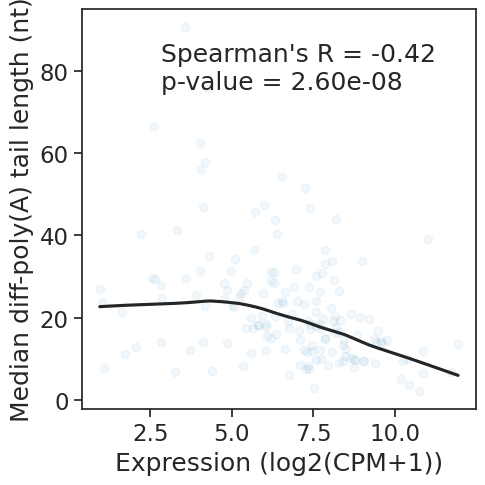

In [105]:
fig, ax = plt.subplots(figsize=(5.2, 5.2))
plt.tight_layout()

merge_holo_longer_df=pd.merge(expression, diff_holo_longer, left_on='transcript_name', right_on='gene')
sns.regplot(
    x=np.log2(merge_holo_longer_df['cpm_holo']+1),
    y=merge_holo_longer_df['median_diff'].astype(float),
    scatter_kws={'alpha': 0.05, 'rasterized': True},
    line_kws={'color': '#252525'},
    lowess=True, ax=ax
)


ax.set_xlabel('Expression (log2(CPM+1))')
ax.set_ylabel('Median diff-poly(A) tail length (nt)')

rho, p = stats.spearmanr(merge_holo_longer_df['cpm_holo'], merge_holo_longer_df['median_diff'].astype(float))

ax.annotate(xy=(0.2, 0.8),
            text=f"Spearman's R = {rho:.2f}\np-value = {p:.2e}",
     xycoords='axes fraction') #xy=(0.67, 0.9)
#ax.axhline(y=rho, color='red', linestyle='--', label=f'ρ={rho:.2f}')

plt.tight_layout()
plt.savefig('median_diff_polya_length_vs_median_expression_holo_only_on_diff_polyA_genes_holo_longer_isoquant.png',dpi=300, transparent=True)
plt.show()

In [106]:
print(rho,p)

-0.4225867717696795 2.6000322990667502e-08


In [107]:
merge_holo_longer_df.shape

(160, 25)

/tmp/ipykernel_800951/3847864932.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s['median_diff']=s['median_diff'].astype(float)
/tmp/ipykernel_800951/3847864932.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s['cpm_holo']=np.log2(s['cpm_holo'])


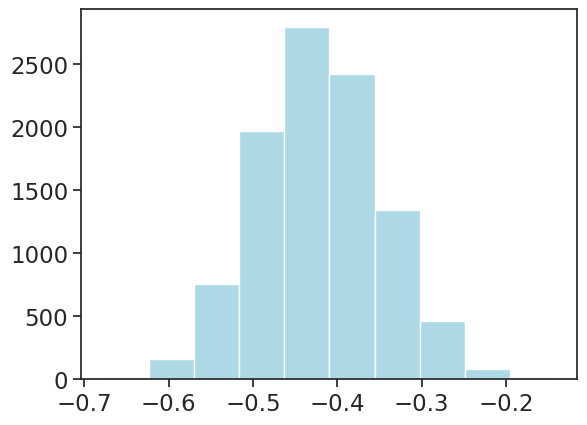

In [109]:
boot_res = []

s = merge_holo_longer_df[['cpm_holo','median_diff']]
s['median_diff']=s['median_diff'].astype(float)
s['cpm_holo']=np.log2(s['cpm_holo'])
n = len(s)

for _ in range(10_000):
    samp = s.sample(n=n, replace=True)
    boot_res.append(stats.spearmanr(samp['cpm_holo'], samp['median_diff'])[0])
plt.hist(boot_res,color='lightblue')
plt.savefig('spearman_bootstrap_distribution_holo_longer_diff_polyA_genes160_isoquant.png',dpi=300, transparent=True)
plt.show()

In [100]:
np.percentile(boot_res, (2.5, 97.5))

array([-0.55734069, -0.27444229])

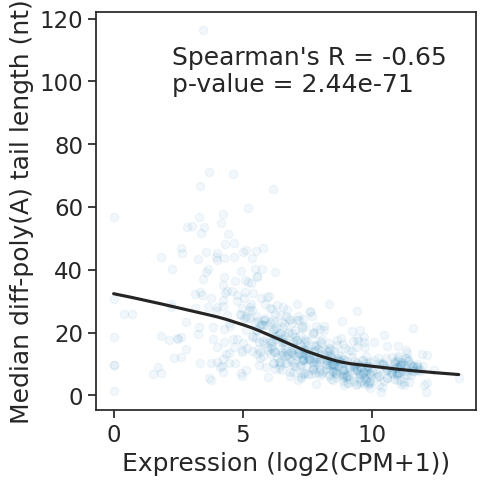

-0.6527097781861914 2.436802001866485e-71


In [110]:
ig, ax = plt.subplots(figsize=(5.2, 5.2))
plt.tight_layout()

merge_apo_longer_df=pd.merge(expression, diff_apo_longer, left_on='transcript_name', right_on='gene')
sns.regplot(
    x=np.log2(merge_apo_longer_df['cpm_apo']+1),
    y=-merge_apo_longer_df['median_diff'].astype(float),
    scatter_kws={'alpha': 0.05, 'rasterized': True},
    line_kws={'color': '#252525'},
    lowess=True, ax=ax
)


ax.set_xlabel('Expression (log2(CPM+1))')
ax.set_ylabel('Median diff-poly(A) tail length (nt)')

rho, p = stats.spearmanr(-merge_apo_longer_df['cpm_apo'], merge_apo_longer_df['median_diff'].astype(float))

ax.annotate(text=f"Spearman's R = {rho:.2f}\np-value = {p:.2e}",
    xy=(0.2, 0.80), xycoords='axes fraction') #xy=(0.67, 0.9)
#ax.axhline(y=rho, color='red', linestyle='--', label=f'ρ={rho:.2f}')

plt.tight_layout()
plt.savefig('median_polya_length_vs_median_expression_apo_longer_diff_polyA_genes577_isoquant.png',dpi=300, transparent=True)
plt.show()
print(rho,p)

In [102]:
merge_apo_longer_df.shape

(577, 25)

/tmp/ipykernel_800951/2176007470.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s['median_diff']=-s['median_diff'].astype(float)
/home/zhonh0b/miniconda3/envs/epigenetic/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipykernel_800951/2176007470.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s['cpm_apo']=np.log2(s['cpm_apo'])


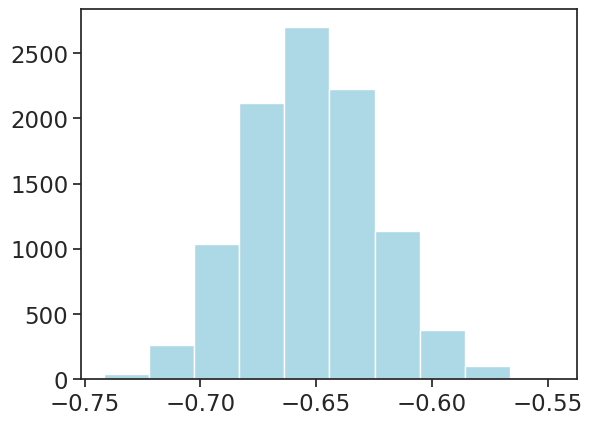

[-0.70424761 -0.59533421]


In [111]:
boot_res = []

s = merge_apo_longer_df[['cpm_apo','median_diff']]
s['median_diff']=-s['median_diff'].astype(float)
s['cpm_apo']=np.log2(s['cpm_apo'])
n = len(s)

for _ in range(10_000):
    samp = s.sample(n=n, replace=True)
    boot_res.append(stats.spearmanr(samp['cpm_apo'], samp['median_diff'])[0])
plt.hist(boot_res,color='lightblue')
plt.savefig('spearman_bootstrap_distribution_apo_longer_diff_polyA_genes577_isoquant.png',dpi=300, transparent=True)
plt.show()
print(np.percentile(boot_res, (2.5, 97.5)))

In [112]:
# try to put all the data toger 
merge_all_diff_expression_df=pd.merge(expression, diff, left_on='transcript_name', right_on='gene')

In [113]:
merge_all_diff_expression_df['cpm']= merge_all_diff_expression_df[['cpm_H1','cpm_H2','cpm_H3','cpm_A1','cpm_A2','cpm_A3']].median(axis=1)

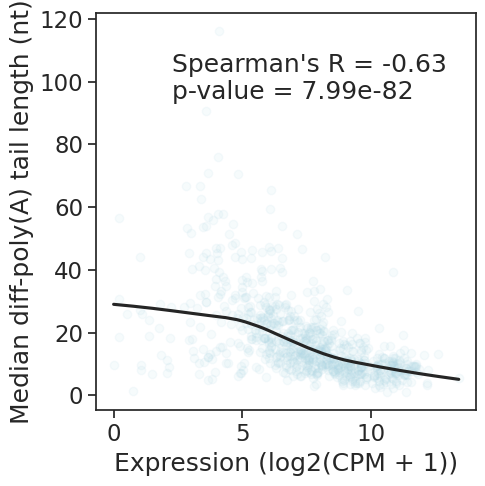

-0.627169076333063 7.989206393941018e-82


In [114]:
fig, ax = plt.subplots(figsize=(5.2, 5.2))

sns.regplot(
    x=np.log2(merge_all_diff_expression_df['cpm'] + 1),
    y=np.abs(merge_all_diff_expression_df['median_diff'].astype(float)),
    scatter_kws={'alpha': 0.1, 'rasterized': True, 'color': 'lightblue'},
    line_kws={'color': '#252525'},
    lowess=True,
    ax=ax
)

ax.set_xlabel('Expression (log2(CPM + 1))')
ax.set_ylabel('Median diff-poly(A) tail length (nt)')

rho, p = stats.spearmanr(
    merge_all_diff_expression_df['cpm'],
    np.abs(merge_all_diff_expression_df['median_diff'].astype(float))
)

ax.annotate(
    f"Spearman's R = {rho:.2f}\np-value = {p:.2e}",
    xy=(0.2, 0.90),
    xycoords='axes fraction',
    ha='left',
    va='top'
)

plt.tight_layout()
plt.savefig(
    'median_polya_length_from_polya_diff_genes_vs_median_expression_6samples_express_all_isoquant.png',
    dpi=300,
    transparent=True
)
plt.show()
print(rho, p)

In [115]:
merge_all_diff_expression_df.shape

(737, 26)

/tmp/ipykernel_800951/3392852486.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s['median_diff']=abs(s['median_diff'].astype(float))
/home/zhonh0b/miniconda3/envs/epigenetic/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipykernel_800951/3392852486.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s['cpm']=np.log2(s['cpm'])


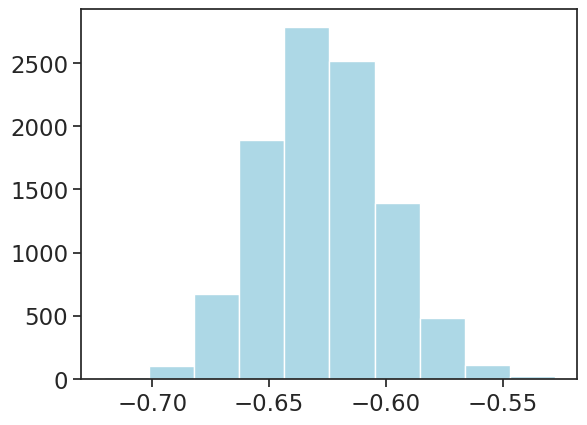

[-0.6757435  -0.57414218]


In [117]:
boot_res = []

s = merge_all_diff_expression_df[['cpm','median_diff']]
s['median_diff']=abs(s['median_diff'].astype(float))
s['cpm']=np.log2(s['cpm'])
n = len(s)

for _ in range(10_000):
    samp = s.sample(n=n, replace=True)
    boot_res.append(stats.spearmanr(samp['cpm'], samp['median_diff'])[0])
plt.hist(boot_res,color='lightblue')
plt.savefig('spearman_bootstrap_distribution_all_diff_polya_genes_6samples_all_isoquant.png',dpi=300, transparent=True)
plt.show()
print(np.percentile(boot_res, (2.5, 97.5)))

In [ ]:
diff.to_csv('diff_polya_genes_between_conditions_6samples_isoquant.csv', index=False)

(951, 10)

# Check the diffPolyA gene and the DEG

Pearson Correlation Coefficient: 0.07793810391972648
pvalue is: 0.5092282869991406


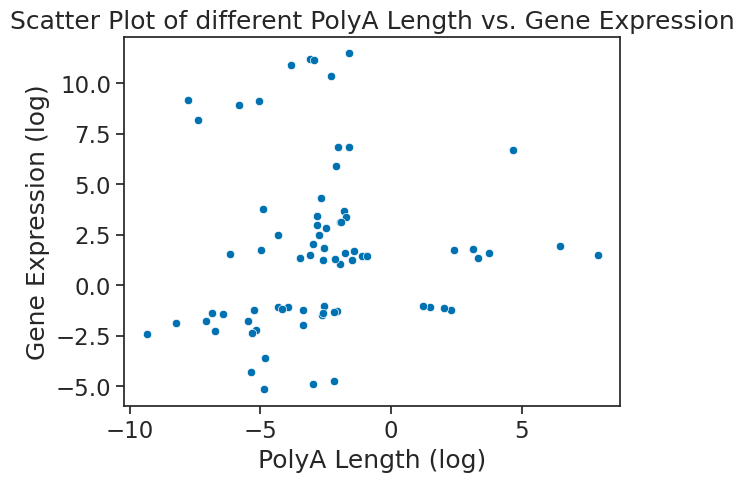

In [118]:
from scipy.stats import pearsonr
# Calculate the correlation coefficient
correlation_coefficient,pvalue= pearsonr(merged_diff_polya_deg_isoquant['log2FC_pollya_length'].astype(float),merged_diff_polya_deg_isoquant['log2FoldChange'].astype(float))

# Print the correlation coefficient
print(f"Pearson Correlation Coefficient: {correlation_coefficient}")
print(f'pvalue is: {pvalue}')
# Create a scatter plot to visualize the correlation
sns.scatterplot(x='log2FC_pollya_length', y='log2FoldChange', data=merged_diff_polya_deg_isoquant)
plt.title('Scatter Plot of different PolyA Length vs. Gene Expression')
plt.xlabel('PolyA Length (log)')
plt.ylabel('Gene Expression (log)')
plt.show()

In [162]:
merged_diff_polya_deg_isoquant.head()

,gene,apo_count,holo_count,median_apo,median_diff,median_holo,u,p-value,FDR,transcript_id,...,A2,A3,H1,H2,H3,Gene,Preferred_name,Description,deg_result,log2FC_pollya_length
0,transcript2289.scaffold297size308578.nnic,4118.0,5555.0,60.695,-9.655000000000001,51.04,13348416.0,5.822672e-45,6.102161e-42,transcript2289.scaffold297size308578.nnic,...,27.450639,72.779893,261.984395,172.757474,156.162944,AIPGENE6868_gene,NaN,neurotransmitter:sodium symporter activity,up,-2.499493
1,AIPGENE19986,685.0,541.0,63.76,46.57,110.33,105742.0,3.336982e-38,2.123274e-35,AIPGENE19986,...,91.959641,424.467966,269.469663,232.476107,268.380536,AIPGENE19986_gene,PHGDH,Belongs to the D-isomer specific 2-hydroxyacid...,up,7.911016
2,transcript1615.scaffold414size184771.nnic,3667.0,2266.0,70.48,-16.820000000000007,53.66,4871692.0,4.825115e-29,1.790922e-26,transcript1615.scaffold414size184771.nnic,...,1829.585094,1172.782034,726.071037,837.127268,1043.702085,AIPGENE5624_gene,NaN,NaN,down,-3.933669
3,transcript1620.scaffold414size184771.nnic,2019.0,1781.0,77.54,-18.150000000000006,59.39,2167713.0,6.135711e-28,1.987524e-25,transcript1620.scaffold414size184771.nnic,...,0.000000,682.861009,371.768332,448.956153,604.248576,AIPGENE5625_gene,NaN,NaN,up,-3.847207
4,AIPGENE21459,11223.0,5702.0,58.77,6.475000000000001,65.245,28779378.0,9.233506e-27,2.570377e-24,AIPGENE21459,...,6544.232355,4759.511928,3685.247152,2675.608045,2774.050279,AIPGENE21459_gene,CAT,Occurs in almost all aerobically respiring org...,down,1.507874


In [163]:
test=merge_all_diff_expression_df[merge_all_diff_expression_df['transcript_name'].isin(merged_diff_polya_deg_isoquant['gene'])]


In [164]:
test['log2FC']=test['cpm_holo']-test['cpm_apo']

/tmp/ipykernel_279725/156505173.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['log2FC']=test['cpm_holo']-test['cpm_apo']


In [165]:
pearsonr(test['log2PolyAFC'].astype(float),test['log2FC'].astype(float))


PearsonRResult(statistic=0.07339490182911515, pvalue=0.5342989731710505)

In [166]:
merge_diff_deg_isoquant_holo_longer_polya=merged_diff_polya_deg_isoquant[merged_diff_polya_deg_isoquant['log2FC_pollya_length'].astype(float)>0] # means holo has longer polya 
merge_diff_deg_isoquant_apo_longer_polya=merged_diff_polya_deg_isoquant[merged_diff_polya_deg_isoquant['log2FC_pollya_length'].astype(float)<0] # means holo has longer polya 

Pearson Correlation Coefficient: 0.18409112121046575
pvalue is: 0.1486562537268473


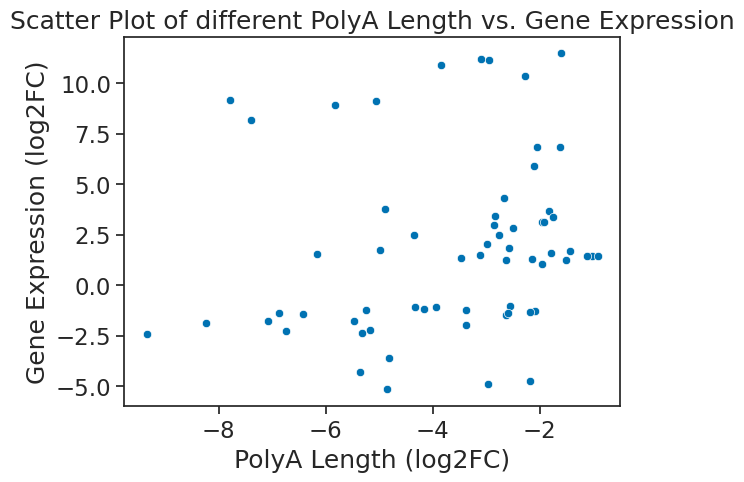

In [167]:
correlation_coefficient,pvalue= pearsonr(merge_diff_deg_isoquant_apo_longer_polya['log2FC_pollya_length'].astype(float),merge_diff_deg_isoquant_apo_longer_polya['log2FoldChange'].astype(float))

# Print the correlation coefficient
print(f"Pearson Correlation Coefficient: {correlation_coefficient}")
print(f'pvalue is: {pvalue}')
# Create a scatter plot to visualize the correlation
sns.scatterplot(x='log2FC_pollya_length', y='log2FoldChange', data=merge_diff_deg_isoquant_apo_longer_polya)
plt.title('Scatter Plot of different PolyA Length vs. Gene Expression')
plt.xlabel('PolyA Length (log2FC)')
plt.ylabel('Gene Expression (log2FC)')
plt.show()

In [168]:
merge_diff_deg_isoquant_holo_longer_polya.columns

Index(['gene', 'apo_count', 'holo_count', 'median_apo', 'median_diff',
       'median_holo', 'u', 'p-value', 'FDR', 'transcript_id', 'baseMean',
       'log2FoldChange', 'lfcSE', 'stat', 'pvalue', 'padj', 'A1', 'A2', 'A3',
       'H1', 'H2', 'H3', 'Gene', 'Preferred_name', 'Description', 'deg_result',
       'log2FC_pollya_length'],
      dtype='object')

Pearson Correlation Coefficient: 0.5222259772144001
pvalue is: 0.09937115858940541


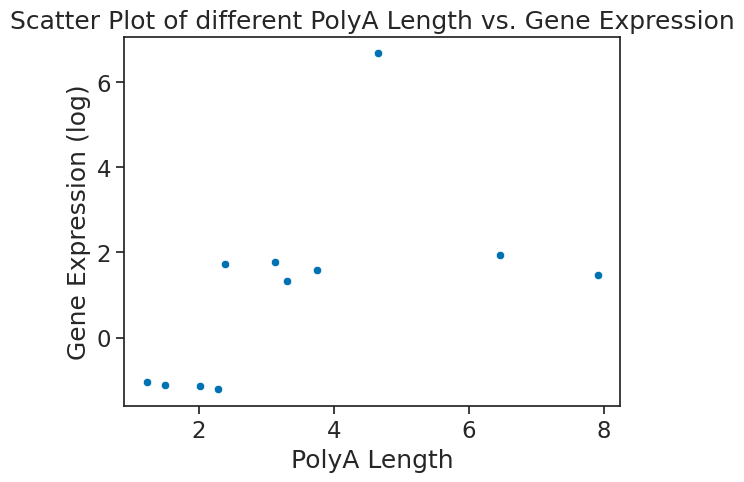

In [169]:
# Calculate the correlation coefficient
correlation_coefficient,pvalue= pearsonr(merge_diff_deg_isoquant_holo_longer_polya['log2FC_pollya_length'].astype(float),merge_diff_deg_isoquant_holo_longer_polya['log2FoldChange'].astype(float))

# Print the correlation coefficient
print(f"Pearson Correlation Coefficient: {correlation_coefficient}")
print(f'pvalue is: {pvalue}')
# Create a scatter plot to visualize the correlation
sns.scatterplot(x='log2FC_pollya_length', y='log2FoldChange', data=merge_diff_deg_isoquant_holo_longer_polya)
plt.title('Scatter Plot of different PolyA Length vs. Gene Expression')
plt.xlabel('PolyA Length')
plt.ylabel('Gene Expression (log)')
plt.show()

Pearson Correlation Coefficient: -0.9399351775736445
pvalue is: 0.06006482242635547


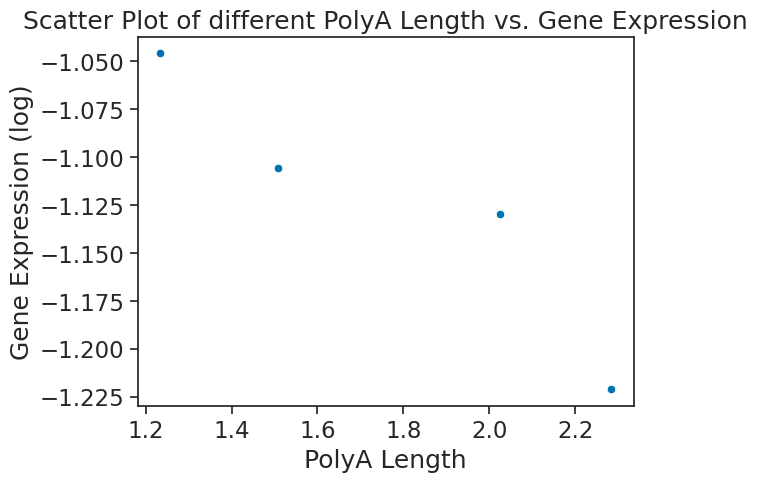

In [170]:
merge_diff_deg_isoquant_holo_longer_polya_down_deg=merge_diff_deg_isoquant_holo_longer_polya[merge_diff_deg_isoquant_holo_longer_polya['log2FoldChange']<0]
# Calculate the correlation coefficient
correlation_coefficient,pvalue= pearsonr(merge_diff_deg_isoquant_holo_longer_polya_down_deg['log2FC_pollya_length'].astype(float),merge_diff_deg_isoquant_holo_longer_polya_down_deg['log2FoldChange'].astype(float))

# Print the correlation coefficient
print(f"Pearson Correlation Coefficient: {correlation_coefficient}")
print(f'pvalue is: {pvalue}')
# Create a scatter plot to visualize the correlation
sns.scatterplot(x='log2FC_pollya_length', y='log2FoldChange', data=merge_diff_deg_isoquant_holo_longer_polya_down_deg)
plt.title('Scatter Plot of different PolyA Length vs. Gene Expression')
plt.xlabel('PolyA Length')
plt.ylabel('Gene Expression (log)')
plt.show()

In [171]:
merge_diff_deg_isoquant_holo_longer_polya_down_deg.shape

(4, 27)

Pearson Correlation Coefficient: 0.034917086686753175
pvalue is: 0.9407590413815915


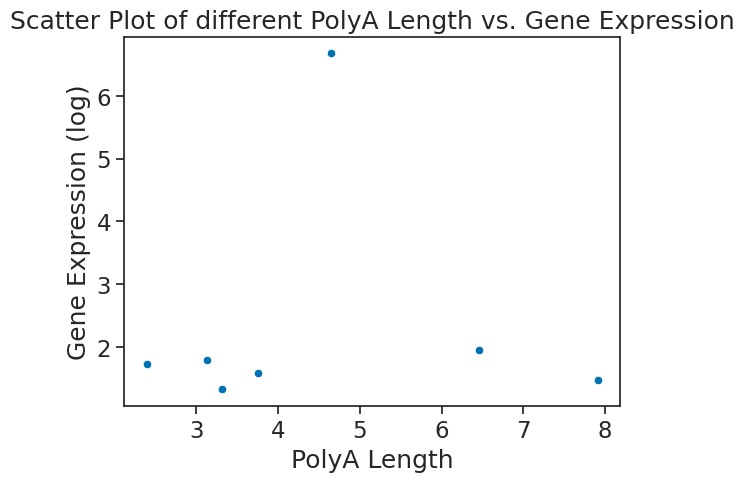

In [172]:
merge_diff_deg_isoquant_holo_longer_polya_up_deg=merge_diff_deg_isoquant_holo_longer_polya[merge_diff_deg_isoquant_holo_longer_polya['log2FoldChange']>0]
# Calculate the correlation coefficient
correlation_coefficient,pvalue= pearsonr(merge_diff_deg_isoquant_holo_longer_polya_up_deg['log2FC_pollya_length'].astype(float),merge_diff_deg_isoquant_holo_longer_polya_up_deg['log2FoldChange'].astype(float))

# Print the correlation coefficient
print(f"Pearson Correlation Coefficient: {correlation_coefficient}")
print(f'pvalue is: {pvalue}')
# Create a scatter plot to visualize the correlation
sns.scatterplot(x='log2FC_pollya_length', y='log2FoldChange', data=merge_diff_deg_isoquant_holo_longer_polya_up_deg)
plt.title('Scatter Plot of different PolyA Length vs. Gene Expression')
plt.xlabel('PolyA Length')
plt.ylabel('Gene Expression (log)')
plt.show()

Pearson Correlation Coefficient: -0.3229020095384684
pvalue is: 0.04800390442593767


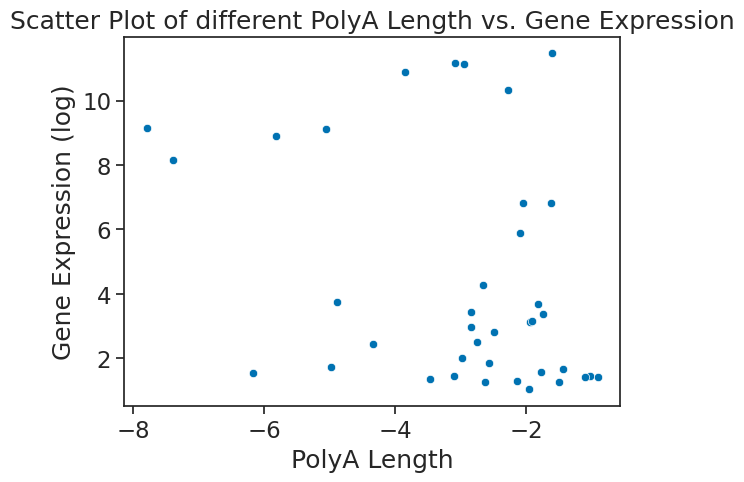

(38, 27)


In [173]:
merge_diff_deg_isoquant_apo_longer_polya_up_deg=merge_diff_deg_isoquant_apo_longer_polya[merge_diff_deg_isoquant_apo_longer_polya['log2FoldChange']>0]
# Calculate the correlation coefficient
correlation_coefficient,pvalue= pearsonr(merge_diff_deg_isoquant_apo_longer_polya_up_deg['log2FC_pollya_length'].astype(float),merge_diff_deg_isoquant_apo_longer_polya_up_deg['log2FoldChange'].astype(float))

# Print the correlation coefficient
print(f"Pearson Correlation Coefficient: {correlation_coefficient}")
print(f'pvalue is: {pvalue}')
# Create a scatter plot to visualize the correlation
sns.scatterplot(x='log2FC_pollya_length', y='log2FoldChange', data=merge_diff_deg_isoquant_apo_longer_polya_up_deg)
plt.title('Scatter Plot of different PolyA Length vs. Gene Expression')
plt.xlabel('PolyA Length')
plt.ylabel('Gene Expression (log)')
plt.show()
print(merge_diff_deg_isoquant_apo_longer_polya_up_deg.shape)

Pearson Correlation Coefficient: -0.005096152701322214
pvalue is: 0.9807119719607229


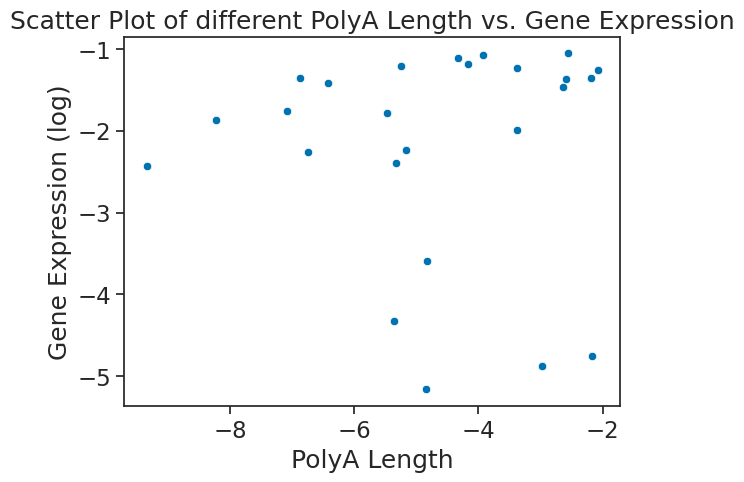

In [174]:
merge_diff_deg_isoquant_apo_longer_polya_down_deg=merge_diff_deg_isoquant_apo_longer_polya[merge_diff_deg_isoquant_apo_longer_polya['log2FoldChange']<0]
# Calculate the correlation coefficient
correlation_coefficient,pvalue= pearsonr(merge_diff_deg_isoquant_apo_longer_polya_down_deg['log2FC_pollya_length'].astype(float),merge_diff_deg_isoquant_apo_longer_polya_down_deg['log2FoldChange'].astype(float))

# Print the correlation coefficient
print(f"Pearson Correlation Coefficient: {correlation_coefficient}")
print(f'pvalue is: {pvalue}')
# Create a scatter plot to visualize the correlation
sns.scatterplot(x='log2FC_pollya_length', y='log2FoldChange', data=merge_diff_deg_isoquant_apo_longer_polya_down_deg)
plt.title('Scatter Plot of different PolyA Length vs. Gene Expression')
plt.xlabel('PolyA Length')
plt.ylabel('Gene Expression (log)')
plt.show()

In [175]:
merged_diff_polya_deg_isoquant.head()

,gene,apo_count,holo_count,median_apo,median_diff,median_holo,u,p-value,FDR,transcript_id,...,A2,A3,H1,H2,H3,Gene,Preferred_name,Description,deg_result,log2FC_pollya_length
0,transcript2289.scaffold297size308578.nnic,4118.0,5555.0,60.695,-9.655000000000001,51.04,13348416.0,5.822672e-45,6.102161e-42,transcript2289.scaffold297size308578.nnic,...,27.450639,72.779893,261.984395,172.757474,156.162944,AIPGENE6868_gene,NaN,neurotransmitter:sodium symporter activity,up,-2.499493
1,AIPGENE19986,685.0,541.0,63.76,46.57,110.33,105742.0,3.336982e-38,2.123274e-35,AIPGENE19986,...,91.959641,424.467966,269.469663,232.476107,268.380536,AIPGENE19986_gene,PHGDH,Belongs to the D-isomer specific 2-hydroxyacid...,up,7.911016
2,transcript1615.scaffold414size184771.nnic,3667.0,2266.0,70.48,-16.820000000000007,53.66,4871692.0,4.825115e-29,1.790922e-26,transcript1615.scaffold414size184771.nnic,...,1829.585094,1172.782034,726.071037,837.127268,1043.702085,AIPGENE5624_gene,NaN,NaN,down,-3.933669
3,transcript1620.scaffold414size184771.nnic,2019.0,1781.0,77.54,-18.150000000000006,59.39,2167713.0,6.135711e-28,1.987524e-25,transcript1620.scaffold414size184771.nnic,...,0.000000,682.861009,371.768332,448.956153,604.248576,AIPGENE5625_gene,NaN,NaN,up,-3.847207
4,AIPGENE21459,11223.0,5702.0,58.77,6.475000000000001,65.245,28779378.0,9.233506e-27,2.570377e-24,AIPGENE21459,...,6544.232355,4759.511928,3685.247152,2675.608045,2774.050279,AIPGENE21459_gene,CAT,Occurs in almost all aerobically respiring org...,down,1.507874


In [179]:
merge_diff_deg_isoquant_apo_longer_polya.to_csv('./merge_diff_deg_isoquant_apo_longer_polya.csv')
merge_diff_deg_isoquant_holo_longer_polya.to_csv('./merge_diff_deg_isoquant_holo_longer_polya.csv')

In [178]:
import statsmodels.api as sm
x = merge_diff_deg_isoquant_apo_longer_polya['log2FC_pollya_length']
y = merge_diff_deg_isoquant_apo_longer_polya['log2FoldChange']
# Add a constant (intercept) to the independent variable
x_with_intercept = sm.add_constant(x)

# Fit the linear regression model
model = sm.OLS(y, x_with_intercept).fit()

# Get the R-squared value
r_squared = model.rsquared

# Get the p-value
p_value = model.pvalues[1]  # p-value for the slope (not the intercept)

# Print the results
print(f"R-squared: {r_squared}")
print(f"P-value: {p_value}")

# For additional regression statistics
print(model.summary())

R-squared: 0.03388954090852647
P-value: 0.1486562537268479
                            OLS Regression Results                            
Dep. Variable:         log2FoldChange   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     2.140
Date:                Mon, 04 May 2026   Prob (F-statistic):              0.149
Time:                        14:21:12   Log-Likelihood:                -179.89
No. Observations:                  63   AIC:                             363.8
Df Residuals:                      61   BIC:                             368.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------